In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import missingno as msno
from datetime import datetime
import os
import glob


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.animation as animation
import datetime
import seaborn as sns
import missingno as msno
from datetime import datetime  # Untuk konversi timestamp ke human-readable
from IPython.display import display, Markdown
sns.set_theme(style="whitegrid")

In [3]:
station_ids = ['id-05']
# Input readable date
start_readable_date = "01-01-2025 00:00:00"  # Format: DD-MM-YYYY HH:MM:SS
end_readable_date = "17-07-2026 23:59:59"  # Format: DD-MM-YYYY HH:MM:SS

# Convert readable date to Unix timestamp
start_timestamp = int(datetime.strptime(start_readable_date, "%d-%m-%Y %H:%M:%S").timestamp())
print(start_timestamp) # Convert to string and print
end_timestamp = int(datetime.strptime(end_readable_date, "%d-%m-%Y %H:%M:%S").timestamp())
print(end_timestamp) # Convert to string and print

1735664400
1784307599


In [4]:
# 1. Menggunakan jalur data CSV hasil Audit Forensik
import os
BASE_DIR = os.path.dirname(os.path.abspath('.'))
folder_path = os.path.join(BASE_DIR, 'Analisis_Meteorologi', 'cache_data')
all_weather_dataframes = {}

print(f" Memulai proses pembacaan data CSV dari '{folder_path}'...")
print("="*65)

if not os.path.exists(folder_path):
    print(f"ERROR: Fatal Error: Folder '{folder_path}' tidak ditemukan!")
else:
    import glob
    import pandas as pd
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

    if len(csv_files) == 0:
        print(f"WARNING: Peringatan: Tidak ada file berekstensi .csv di dalamnya.")
    else:
        for file_path in csv_files:
            try:
                nama_file = os.path.basename(file_path)
                # Format file: id-03_raw.csv
                station_id = nama_file.split('_')[0]
                if station_id not in ['id-05']:
                    continue

                df = pd.read_csv(file_path)

                # --- KONVERSI WAKTU STANDAR ---
                if 'timestamp' in df.columns:
                    # Konversi unix timestamp ke datetime Asia/Bangkok
                    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', utc=True).dt.tz_convert('UTC')
                    df = df.sort_values('timestamp').set_index('timestamp')

                all_weather_dataframes[station_id] = df
                print(f"OK: Berhasil memuat: {nama_file} -> Stasiun '{station_id}' ({len(df):,} baris data)")

            except Exception as e:
                print(f"ERROR: Gagal membaca file '{nama_file}'. Detail Error: {e}")

print("="*65)
print("Proses Muat Data Selesai! Data siap dilanjutkan ke tahap Reindexing dan Filtering.")


 Memulai proses pembacaan data CSV dari 'd:\Github\Projek_Rainfall\Analisis_Meteorologi\cache_data'...
OK: Berhasil memuat: id-05_raw.csv -> Stasiun 'id-05' (807,385 baris data)
Proses Muat Data Selesai! Data siap dilanjutkan ke tahap Reindexing dan Filtering.


In [5]:
import os
import pandas as pd
BASE_DIR = os.path.dirname(os.path.abspath('.'))
print(" Memuat Data Satelit Referensi ERA5 AWOS Features...")
ERA5_PATH = os.path.join(BASE_DIR, 'Google_Earth_Engine', 'Data_Satelit', 'ERA5_Hourly_All_Requested_Features_2000_2026.csv')
GSMAP_PATH = os.path.join(BASE_DIR, 'Google_Earth_Engine', 'Data_Satelit', 'Rainfall_GSMaP_TimeSeries_UNIX.csv')
IMERG_PATH = os.path.join(BASE_DIR, 'Google_Earth_Engine', 'Data_Satelit', 'Rainfall_IMERG_TimeSeries_UNIX.csv')
OYA_PATH = os.path.join(BASE_DIR, 'Google_Earth_Engine', 'Data_Satelit', 'Rainfall_Oya_TimeSeries_UNIX.csv')

df_era5 = pd.read_csv(ERA5_PATH)

df_era5['timestamp'] = pd.to_datetime(df_era5['datetime_utc']).dt.tz_localize('UTC').dt.tz_convert('UTC')
df_era5 = df_era5.set_index('timestamp')

era5_mapping = {
    'temperature': 'temperature_era5',
    'humidity': 'humidity_era5',
    'pressure': 'pressure_era5',
    'dew': 'dewpoint_era5',
    'rainrate': 'rain_mm',
}
print(f"OK: ERA5 Siap! Dimensi: {df_era5.shape} (Zona Waktu: {df_era5.index.tz})")
print("="*65)


 Memuat Data Satelit Referensi ERA5 AWOS Features...
OK: ERA5 Siap! Dimensi: (249768, 25) (Zona Waktu: UTC)


In [6]:
# ==============================================================================
# 1. FUNGSI PIPELINE: REINDEXING MUTLAK + HAMPEL + IMPUTASI HIBRIDA + QC FLAGS
# ==============================================================================
import os
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

def load_multi_satellite_rain(start_time, end_time):
    master_index = pd.date_range(start=start_time, end=end_time, freq='h', tz='UTC')
    # IMERG
    df_imerg = pd.read_csv(IMERG_PATH)
    df_imerg['timestamp'] = pd.to_datetime(df_imerg['datetime_utc'], utc=True)
    df_imerg_hourly = df_imerg.set_index('timestamp').resample('1h').sum().reindex(master_index)['precipitation']

    # GSMaP
    df_gsmap = pd.read_csv(GSMAP_PATH)
    df_gsmap['timestamp'] = pd.to_datetime(df_gsmap['datetime_utc'], utc=True)
    df_gsmap_hourly = df_gsmap.set_index('timestamp').resample('1h').sum().reindex(master_index)['hourlyPrecipRateGC']
    
    # Oya
    df_oya = pd.read_csv(OYA_PATH)
    df_oya['timestamp'] = pd.to_datetime(df_oya['datetime_utc'], utc=True)
    df_oya_hourly = df_oya.set_index('timestamp').resample('1h').sum().reindex(master_index)['precipitation_mmhr']
    
    # Gabungkan
    df_rain_sat = pd.DataFrame({
        #'imerg': df_imerg_hourly,
        'gsmap': df_gsmap_hourly,
        'oya': df_oya_hourly
    })
    
    # Nilai Tengah (Median)
    median_rain = df_rain_sat.mean(axis=1).fillna(0.0)
    print(f"[OK] Konsensus Hujan Satelit Siap (Nilai Maksimal Median: {median_rain.max():.2f} mm)")
    return median_rain

def bersihkan_data_hourly(df_hourly, df_era5_reference, df_rain_median, start_time, end_time):
    print(f"Memulai Pipeline Imputasi Hibrida | Rentang: {start_time} s.d {end_time}")

    if df_hourly.index.tz is None:
        df_hourly.index = df_hourly.index.tz_localize('UTC')
    else:
        df_hourly.index = df_hourly.index.tz_convert('UTC')

    # --- TAHAP 1: REINDEXING MUTLAK ---
    master_index = pd.date_range(start=start_time, end=end_time, freq='h', tz='UTC') 

    df_reindexed = df_hourly.reindex(master_index)
    df_reindexed.index.name = 'timestamp'

    df_raw = df_reindexed.copy()

    # --- TAHAP 2: HAMPEL FILTER, IMPUTASI HIBRIDA, DAN QC FLAGS ---
    kolom_sensor = ['temperature', 'humidity', 'pressure', 'dew']
    window = 12
    n_sigmas = 3

    for col in kolom_sensor:
        if col in df_reindexed.columns:
            # 0. Buat QC Flag: 0 = Data Asli, 1 = Imputasi
            qc_col = f'is_imputed_{col}'
            df_reindexed[qc_col] = df_reindexed[col].isnull().astype(int)

            # 1. Deteksi Outlier dengan Hampel Filter
            rolling_median = df_reindexed[col].rolling(window=window, center=True).median()
            deviasi = np.abs(df_reindexed[col] - rolling_median)
            mad = deviasi.rolling(window=window, center=True).median()
            threshold = n_sigmas * 1.4826 * mad
            outlier_idx = deviasi > threshold

            # Hancurkan outlier
            df_reindexed.loc[outlier_idx, col] = np.nan
            df_reindexed.loc[outlier_idx, qc_col] = 1 # Tandai sebagai imputed karena dibuang

            # 2. Imputasi PCHIP (HANYA UNTUK LUBANG KECIL MAKSIMAL 4 JAM)
            df_reindexed[col] = df_reindexed[col].interpolate(
                method='pchip', 
                limit=4,  
                limit_direction='forward'
            )

            # 3. SUBSTITUSI ERA5 DENGAN BIAS CORRECTION (UNTUK SISA LUBANG RAKSASA)
            nama_kolom_era5 = era5_mapping.get(col)
            if nama_kolom_era5 and nama_kolom_era5 in df_era5_reference.columns:
                # Kalkulasi Bias (IoT Asli vs ERA5) di mana keduanya tidak NaN
                valid_mask = df_reindexed[col].notnull() & df_era5_reference[nama_kolom_era5].notnull()
                if valid_mask.sum() > 0:
                    iot_valid = df_reindexed.loc[valid_mask, col]
                    era5_valid = df_era5_reference.loc[valid_mask, nama_kolom_era5]
                    bias = (iot_valid - era5_valid).mean()
                    mae = (iot_valid - era5_valid).abs().mean()
                    print(f"   -> [Bias Correction] {col.upper():<12}: MBE = {bias:>+7.2f} | MAE = {mae:>5.2f}")
                    era5_terkoreksi = df_era5_reference[nama_kolom_era5] + bias
                else:
                    era5_terkoreksi = df_era5_reference[nama_kolom_era5]
                df_reindexed[col] = df_reindexed[col].fillna(era5_terkoreksi)

            # Tambalan darurat
            df_reindexed[col] = df_reindexed[col].bfill().ffill()

            # --- TAHAP KHUSUS: HARD CONSTRAINTS ---
            if col == 'humidity':
                df_reindexed[col] = df_reindexed[col].clip(0, 100)
            elif col == 'lux':
                df_reindexed[col] = df_reindexed[col].clip(lower=0)

    # --- TAHAP KHUSUS: KOREKSI BIAS RADIASI SUHU, KELEMBABAN, & DEWPOINT (DIURNAL REPLACEMENT) ---
    col_temp = 'temperature'
    col_hum = 'humidity'
    col_dew = 'dew'
    
    nama_kolom_temp = era5_mapping.get(col_temp)
    nama_kolom_hum = era5_mapping.get(col_hum)
    nama_kolom_dew = era5_mapping.get(col_dew)
    
    if (col_temp in df_reindexed.columns and nama_kolom_temp and nama_kolom_temp in df_era5_reference.columns and
        col_hum in df_reindexed.columns and nama_kolom_hum and nama_kolom_hum in df_era5_reference.columns and
        col_dew in df_reindexed.columns and nama_kolom_dew and nama_kolom_dew in df_era5_reference.columns):
        
        print(f"   -> [Diurnal Correction] Mengoreksi bias radiasi untuk suhu, kelembaban, dan dewpoint siang hari...")
        
        # Penyelarasan indeks ERA5 agar panjangnya sama dengan AWS (reindex)
        df_era5_aligned = df_era5_reference.reindex(df_reindexed.index)
        
        # 1. Definisikan jam malam hari (12:00 - 00:00 UTC) dan jam siang hari (02:00 - 09:00 UTC)
        night_hours = (df_reindexed.index.hour >= 12) | (df_reindexed.index.hour <= 0)
        day_hours = (df_reindexed.index.hour >= 2) & (df_reindexed.index.hour <= 9)
        
        # 2. Hitung bias malam hari (AWS - ERA5) untuk masing-masing parameter
        bias_temp = (df_reindexed.loc[night_hours, col_temp] - df_era5_aligned.loc[night_hours, nama_kolom_temp]).mean()
        bias_hum = (df_reindexed.loc[night_hours, col_hum] - df_era5_aligned.loc[night_hours, nama_kolom_hum]).mean()
        bias_dew = (df_reindexed.loc[night_hours, col_dew] - df_era5_aligned.loc[night_hours, nama_kolom_dew]).mean()
        
        # Isi NaN jika terjadi kekosongan data
        bias_temp = 0.0 if np.isnan(bias_temp) else bias_temp
        bias_hum = 0.0 if np.isnan(bias_hum) else bias_hum
        bias_dew = 0.0 if np.isnan(bias_dew) else bias_dew
        
        # 3. Tandai data yang terindikasi terkena bias radiasi (suhu > 34°C pada siang hari)
        biased_mask = (df_reindexed[col_temp] > 34.0) & day_hours
        
        # 4. Ganti ketiga variabel sekaligus menggunakan data ERA5 + bias malam hari
        df_reindexed.loc[biased_mask, col_temp] = df_era5_aligned.loc[biased_mask, nama_kolom_temp] + bias_temp
        df_reindexed.loc[biased_mask, col_hum] = df_era5_aligned.loc[biased_mask, nama_kolom_hum] + bias_hum
        df_reindexed.loc[biased_mask, col_dew] = df_era5_aligned.loc[biased_mask, nama_kolom_dew] + bias_dew
        
        # Clip batas kelembaban agar tidak melebihi 100% atau kurang dari 0%
        df_reindexed[col_hum] = df_reindexed[col_hum].clip(0, 100)

    # --- Penanganan Khusus Hujan
    col = 'rainrate'
    if col in df_reindexed.columns:
        qc_col = f'is_imputed_{col}'
        df_reindexed[qc_col] = df_reindexed[col].isnull().astype(int)
        # Tambal hujan IoT yang bolong menggunakan data median satelit
        print(f"   -> [Rainfall Injection] Menginjeksi data hujan dari Konsensus Satelit (Median)...")
        df_reindexed[col] = df_reindexed[col].fillna(df_rain_median)
        # Jika masih ada yang kosong, anggap tidak hujan (0.0)
        df_reindexed[col] = df_reindexed[col].fillna(0.0)

    print("OK: Pipeline Selesai! Data sudah Terstandarisasi Mutlak dengan QC Flags.")
    return df_raw, df_reindexed






In [7]:
# ==============================================================================
#  FORENSIC ANALYSIS 1: 1-MINUTE RESAMPLING & GAP DETECTION
# ==============================================================================

forensic_data = {}
gap_reports = {}

print(" INITIATING 1-MINUTE RESAMPLING FORENSICS...")

for station_id, df in all_weather_dataframes.items():
    print(f"\n Processing Station: {station_id}")

    if df.empty:
        continue

    start_time = df.index.min()
    end_time = df.index.max()

    # Reindex to strict 1-minute
    master_index = pd.date_range(start=start_time, end=end_time, freq='1min', tz='UTC')
    df_resampled = df.reindex(master_index)
    df_resampled.index.name = 'timestamp'

    expected_obs = len(master_index)
    actual_obs = len(df)
    missing_obs = expected_obs - actual_obs
    completeness = (actual_obs / expected_obs) * 100

    # Gap Analysis using Boolean Mask
    is_missing = df_resampled['temperature'].isnull()

    missing_groups = (is_missing != is_missing.shift()).cumsum()
    gaps = df_resampled[is_missing].groupby(missing_groups).apply(
        lambda x: pd.Series({
            'start': x.index.min(),
            'end': x.index.max(),
            'duration': x.index.max() - x.index.min(),
            'records_missing': len(x)
        })
    )

    if len(gaps) > 0:
        longest_gap = gaps['duration'].max()
        outage_count = len(gaps)
    else:
        longest_gap = pd.Timedelta(seconds=0)
        outage_count = 0

    print(f"Expected 1-min observations: {expected_obs:,}")
    print(f"Actual observations: {actual_obs:,}")
    print(f"Missing observations: {missing_obs:,}")
    print(f"Completeness: {completeness:.2f}%")
    print(f"Outages detected: {outage_count:,}")
    print(f"Longest Gap: {longest_gap}")

    if len(gaps) > 0:
        print("\nTop 5 Longest Outages:")
        print(gaps.sort_values(by='duration', ascending=False).head(5))

    forensic_data[station_id] = df_resampled
    gap_reports[station_id] = gaps

 INITIATING 1-MINUTE RESAMPLING FORENSICS...

 Processing Station: id-05
Expected 1-min observations: 706,890
Actual observations: 807,385
Missing observations: -100,495
Completeness: 114.22%
Outages detected: 293
Longest Gap: 134 days 01:13:00

Top 5 Longest Outages:
                                start                       end  \
temperature                                                       
98          2025-05-06 05:22:37+00:00 2025-09-17 06:35:37+00:00   
110         2025-11-22 14:59:37+00:00 2026-01-31 06:05:37+00:00   
104         2025-10-11 00:52:37+00:00 2025-11-22 14:18:37+00:00   
586         2026-06-22 18:09:37+00:00 2026-07-23 04:10:37+00:00   
102         2025-09-17 18:40:37+00:00 2025-10-11 00:19:37+00:00   

                     duration  records_missing  
temperature                                     
98          134 days 01:13:00           193034  
110          69 days 15:06:00           100267  
104          42 days 13:26:00            61287  
586          30 


 VISUALIZING STATION: id-05
Dataset very large. Downsampling to 15-min strictly for Missingno visualization.


C:\Users\acer\AppData\Local\Temp\ipykernel_9420\1164133793.py:14: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  plot_df = df_resampled.resample('1d').mean()


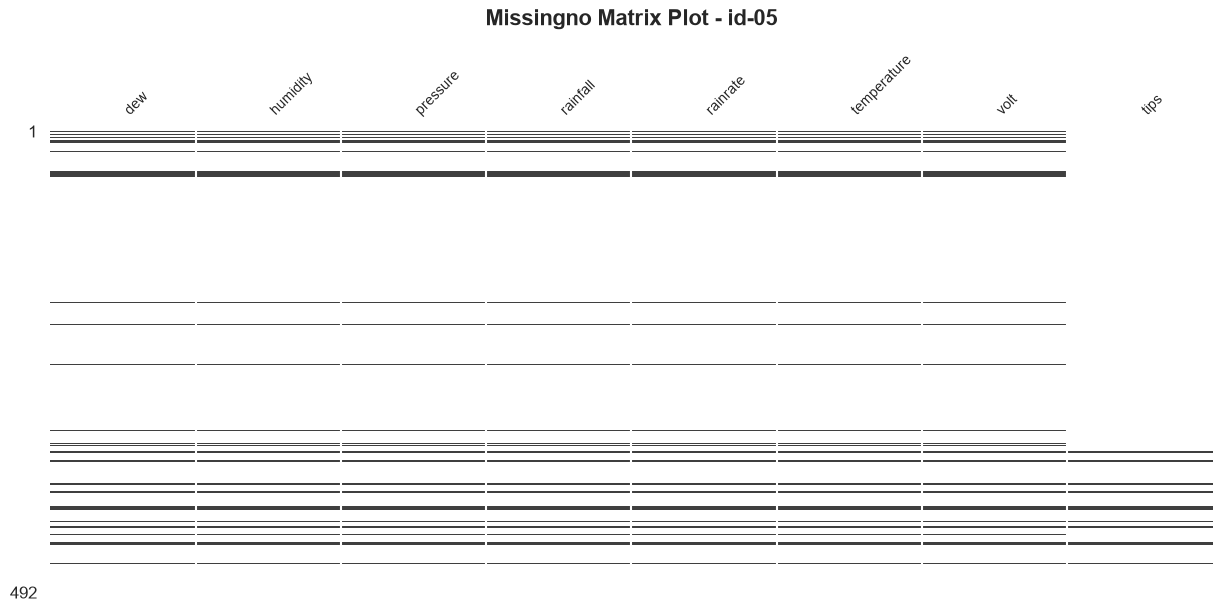

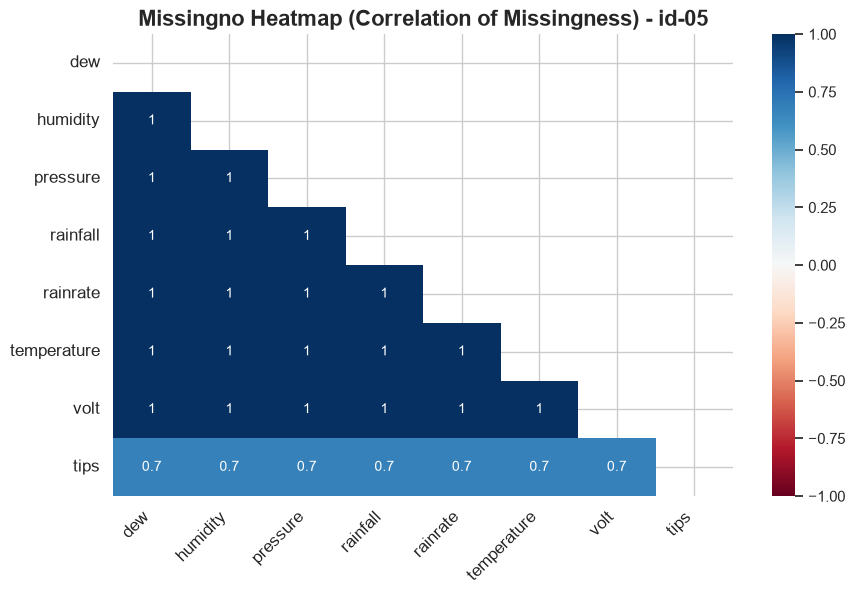

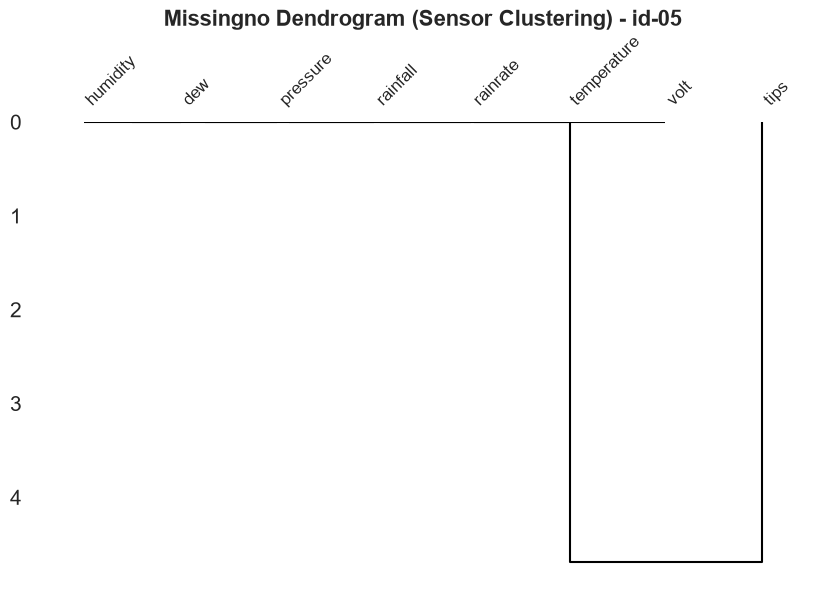

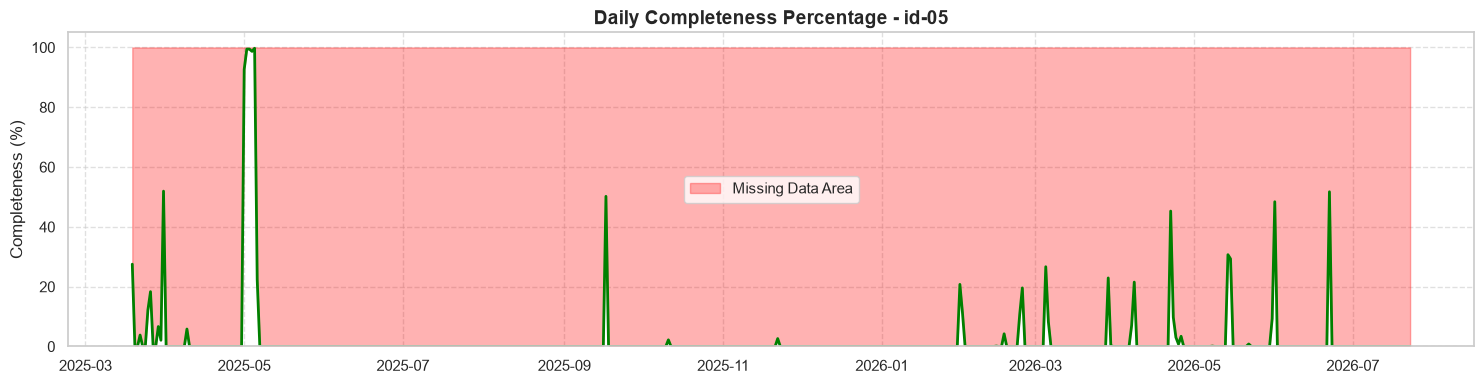

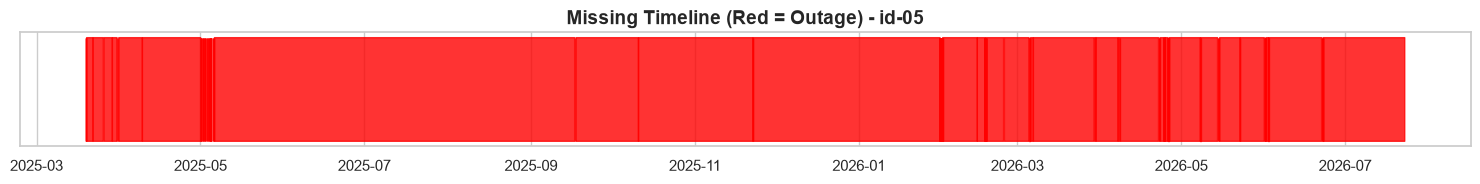

In [8]:
# ==============================================================================
#  FORENSIC ANALYSIS 2: VISUALIZATIONS (MISSINGNO & MATPLOTLIB)
# ==============================================================================
import missingno as msno
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

for station_id, df_resampled in forensic_data.items():
    print(f"\n{'='*50}\n VISUALIZING STATION: {station_id}\n{'='*50}")

    # Downsample for Missingno if data > 500k rows to prevent RAM crash
    if len(df_resampled) > 500000:
        print("Dataset very large. Downsampling to 15-min strictly for Missingno visualization.")
        plot_df = df_resampled.resample('1d').mean()
    else:
        plot_df = df_resampled

    # 1. Missingno Matrix
    fig = plt.figure(figsize=(15, 6))
    ax = fig.add_subplot(111)
    msno.matrix(plot_df, ax=ax, sparkline=False, fontsize=10)
    ax.set_title(f"Missingno Matrix Plot - {station_id}", fontsize=16, fontweight='bold', pad=20)
    # plt.show()

    # 2. Missingno Heatmap
    if plot_df.isnull().sum().sum() > 0:
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111)
        msno.heatmap(plot_df, ax=ax, fontsize=12)
        ax.set_title(f"Missingno Heatmap (Correlation of Missingness) - {station_id}", fontsize=16, fontweight='bold')
        # plt.show()

        # 3. Missingno Dendrogram
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(111)
        msno.dendrogram(plot_df, ax=ax, fontsize=12)
        ax.set_title(f"Missingno Dendrogram (Sensor Clustering) - {station_id}", fontsize=16, fontweight='bold')
        # plt.show()

    # 4. Matplotlib Daily Completeness Plot
    daily_completeness = df_resampled['temperature'].notnull().resample('D').mean() * 100

    plt.figure(figsize=(15, 4))
    plt.plot(daily_completeness.index, daily_completeness.values, color='green', lw=2)
    plt.fill_between(daily_completeness.index, daily_completeness.values, 100, color='red', alpha=0.3, label='Missing Data Area')
    plt.title(f"Daily Completeness Percentage - {station_id}", fontsize=14, fontweight='bold')
    plt.ylabel("Completeness (%)")
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    # plt.show()

    # 5. Missing Timeline Gantt Chart
    plt.figure(figsize=(15, 2))
    missing_series = df_resampled['temperature'].isnull().astype(int)

    plt.fill_between(missing_series.index, 0, missing_series, where=missing_series==1, color='red', alpha=0.8)
    plt.title(f"Missing Timeline (Red = Outage) - {station_id}", fontsize=14, fontweight='bold')
    plt.yticks([])
    plt.tight_layout()
    # plt.show()

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_station_trends(data_dict, column_to_plot, freq='d', agg_method='mean'):
    """
    Membuat plot tren perbandingan dengan metode agregasi dinamis.
    """
    # 1. Konfigurasi Label Frekuensi (KODE DIPERBAIKI KE STANDAR PANDAS BARU)
    freq_config = {
        'd': {'label': 'Harian', 'xlabel': 'Tanggal', 'code': 'd'}, 
        'h': {'label': 'Per Jam', 'xlabel': 'Waktu (Jam)', 'code': 'h'},
        'min': {'label': 'Per Menit', 'xlabel': 'Waktu (Menit)', 'code': 'min'}
    }

    selected_freq = freq_config.get(freq, freq_config['d'])

    # 2. Konfigurasi Label Agregasi
    agg_labels = {
        'mean': 'Rata-rata',
        'median': 'Median (Nilai Tengah)',
        'max': 'Maksimum (Tertinggi)',
        'min': 'Minimum (Terendah)',
        'sum': 'Total Akumulasi'
    }
    agg_display_name = agg_labels.get(agg_method, agg_method.capitalize())

    # Mulai Plotting
    plt.figure(figsize=(15, 7))
    plot_berhasil = False # Penanda apakah ada yang berhasil di-plot

    # Loop stasiun
    for station_id, df in data_dict.items():
        if column_to_plot not in df.columns:
            print(f"WARNING: Peringatan: Kolom '{column_to_plot}' tidak ada di {station_id}. Skip.")
            continue

        temp_df = df.copy()

        # --- PERBAIKAN 1: Pastikan timestamp bisa diakses ---
        if 'timestamp' not in temp_df.columns and temp_df.index.name == 'timestamp':
            temp_df = temp_df.reset_index()

        # Pastikan timestamp adalah datetime
        if not pd.api.types.is_datetime64_any_dtype(temp_df['timestamp']):
             temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])

        # --- PERBAIKAN 2: Paksa kolom target menjadi numerik murni ---
        # Jika Firebase mengirim string "28", ini akan memaksanya jadi float 28.0
        temp_df[column_to_plot] = pd.to_numeric(temp_df[column_to_plot], errors='coerce')

        # 3. PROSES GROUPING & AGREGASI DINAMIS
        time_col = f'time_group_{freq}'
        temp_df[time_col] = temp_df['timestamp'].dt.floor(selected_freq['code'])

        # Lakukan agregasi. Dropna() mencegah eror jika ada data kosong.
        trend_data = temp_df.groupby(time_col)[column_to_plot].agg(agg_method).dropna().reset_index()

        # Jika setelah agregasi datanya kosong, lewati
        if trend_data.empty:
            print(f"WARNING: Peringatan: Data agregasi untuk {station_id} kosong.")
            continue

        # --- PERBAIKAN 3: Tambahkan marker='o' ---
        # Ini memastikan jika datanya hanya 1 titik, titik tersebut akan tetap terlihat!
        plt.plot(
            trend_data[time_col], 
            trend_data[column_to_plot], 
            label=station_id, 
            alpha=0.8, 
            )
        plot_berhasil = True

    # 4. Mempercantik Visualisasi
    plt.xlabel(selected_freq['xlabel'], fontsize=12)
    plt.ylabel(f"{agg_display_name} {column_to_plot.replace('_', ' ').capitalize()}", fontsize=12)
    plt.title(f"Perbandingan {agg_display_name} {column_to_plot} ({selected_freq['label']})", 
              fontsize=14, fontweight='bold')

    if plot_berhasil:
        plt.legend()
    else:
        plt.text(0.5, 0.5, 'TIDAK ADA DATA VALID UNTUK DITAMPILKAN', 
                 ha='center', va='center', fontsize=16, color='red', transform=plt.gca().transAxes)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    # plt.show()

# CARA PEMANGGILAN:
#plot_station_trends(all_weather_dataframes, 'temperature', freq='h', agg_method='max')

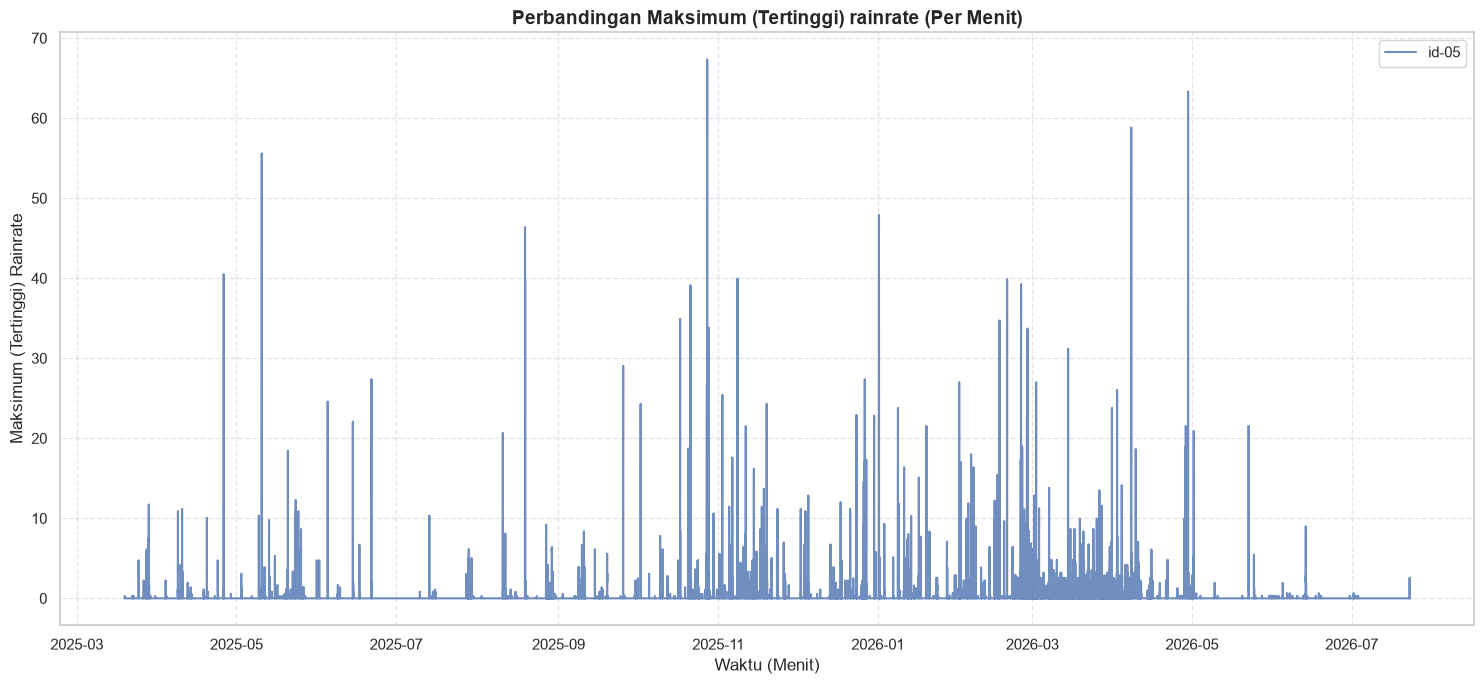

In [10]:
plot_station_trends(all_weather_dataframes, 'rainrate', freq='min', agg_method='max')

Menampilkan plot perbandingan per jam...


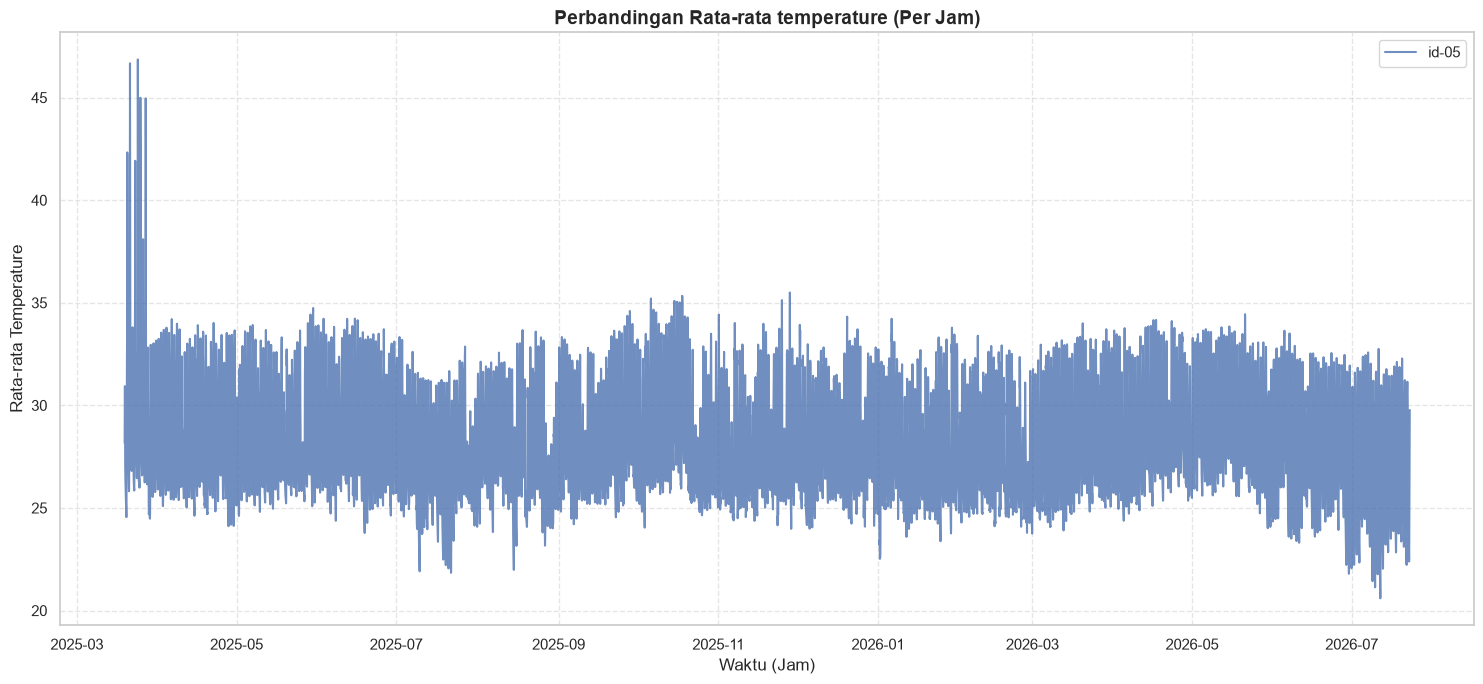

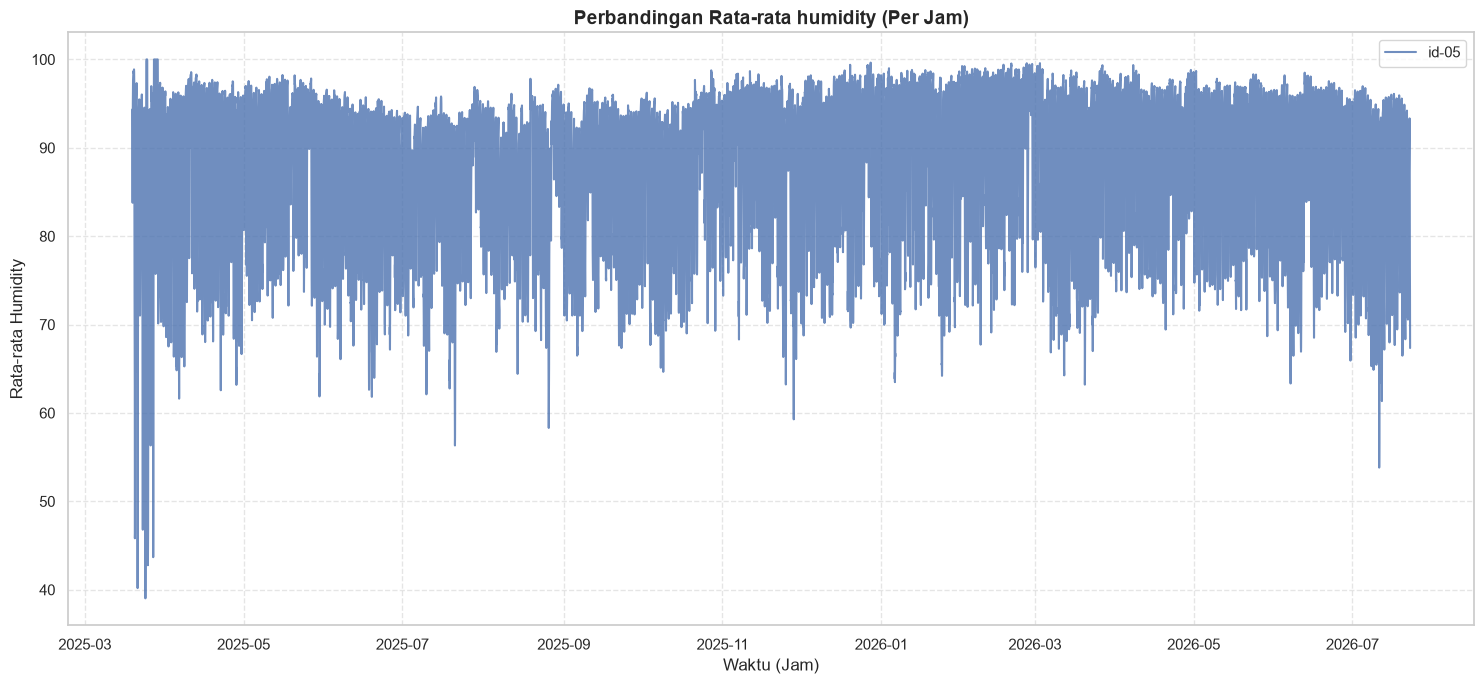

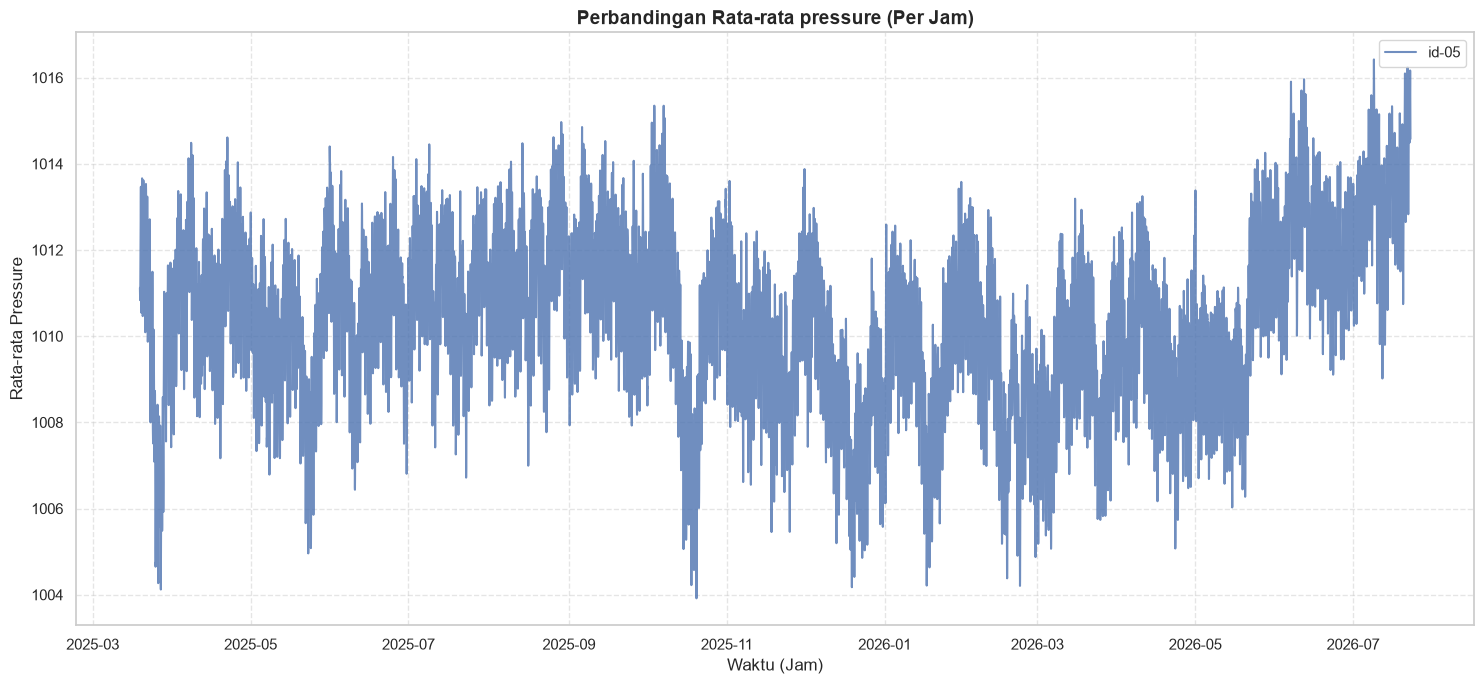

In [11]:
# --- 1. Membuat Plot Rata-rata PER JAM ---
# Cukup atur freq='h'
print("Menampilkan plot perbandingan per jam...")
plot_station_trends(all_weather_dataframes, 'temperature', freq='h', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'humidity', freq='h', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'pressure', freq='h', agg_method='mean')


Menampilkan plot perbandingan per hari...


C:\Users\acer\AppData\Local\Temp\ipykernel_9420\2449037579.py:53: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  temp_df[time_col] = temp_df['timestamp'].dt.floor(selected_freq['code'])
C:\Users\acer\AppData\Local\Temp\ipykernel_9420\2449037579.py:53: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  temp_df[time_col] = temp_df['timestamp'].dt.floor(selected_freq['code'])
C:\Users\acer\AppData\Local\Temp\ipykernel_9420\2449037579.py:53: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  temp_df[time_col] = temp_df['timestamp'].dt.floor(selected_freq['code'])
C:\Users\acer\AppData\Local\Temp\ipykernel_9420\2449037579.py:53: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  temp_df[time_col] = temp_df['timestamp'].dt.floor(selected_freq['code'])


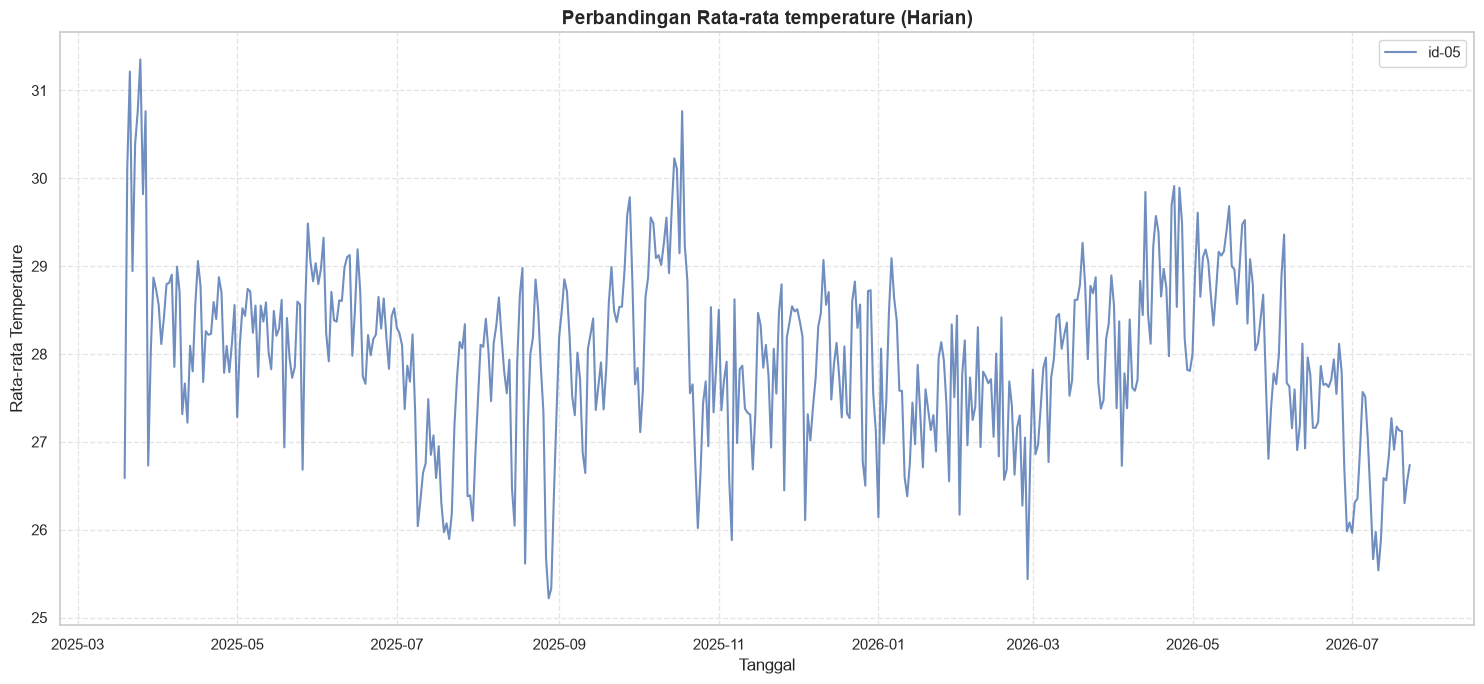

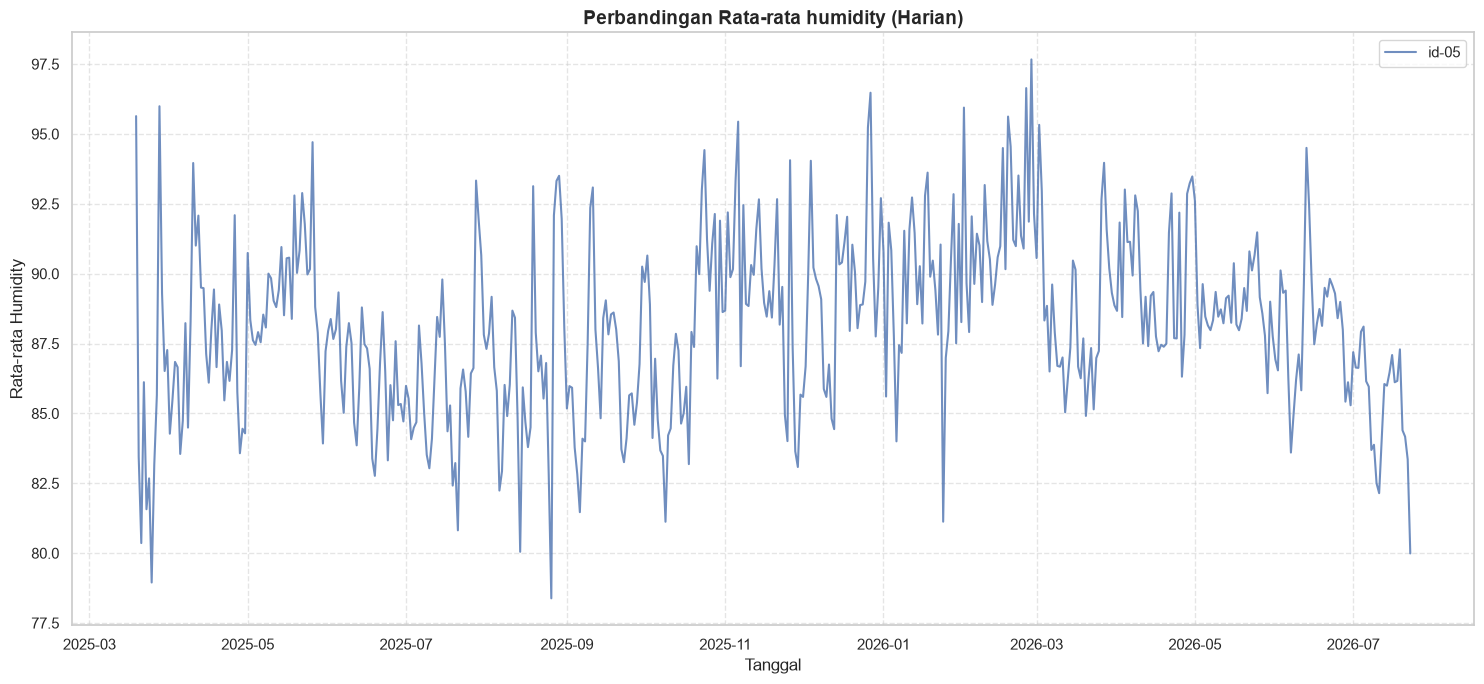

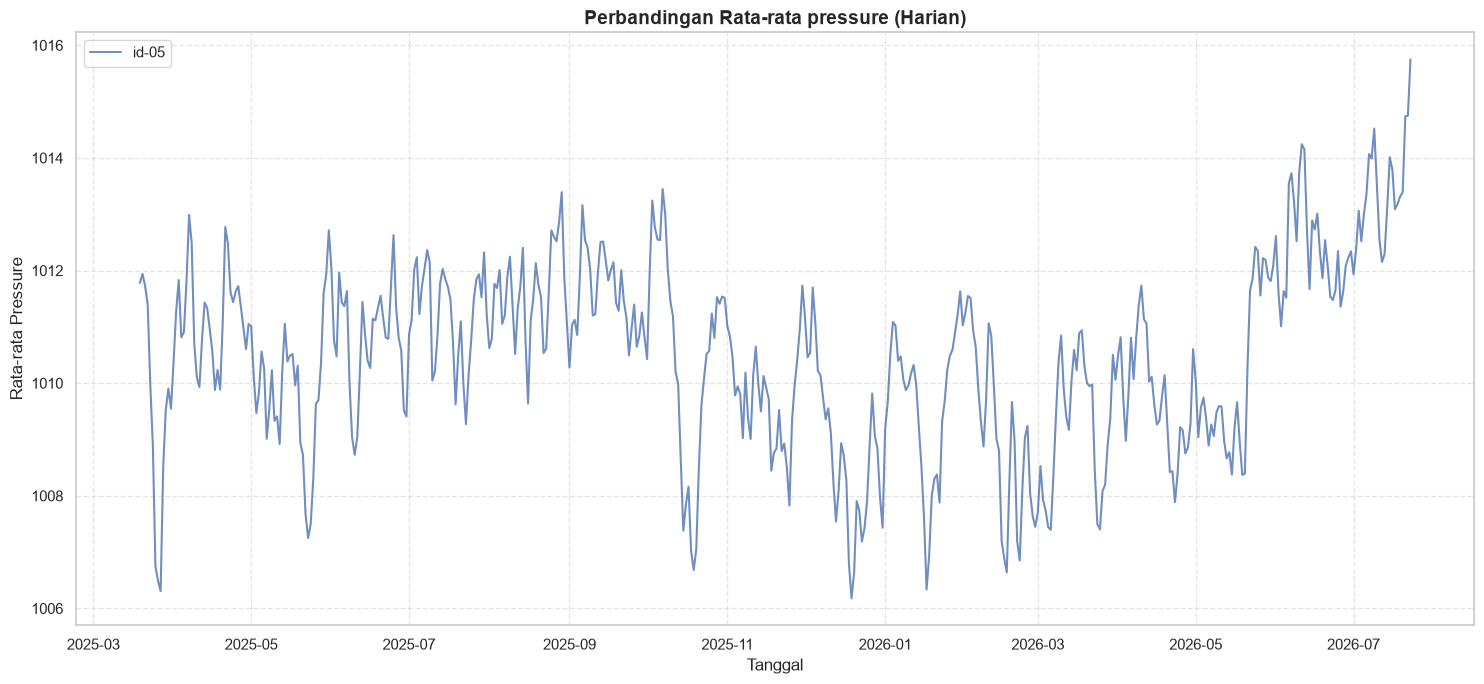

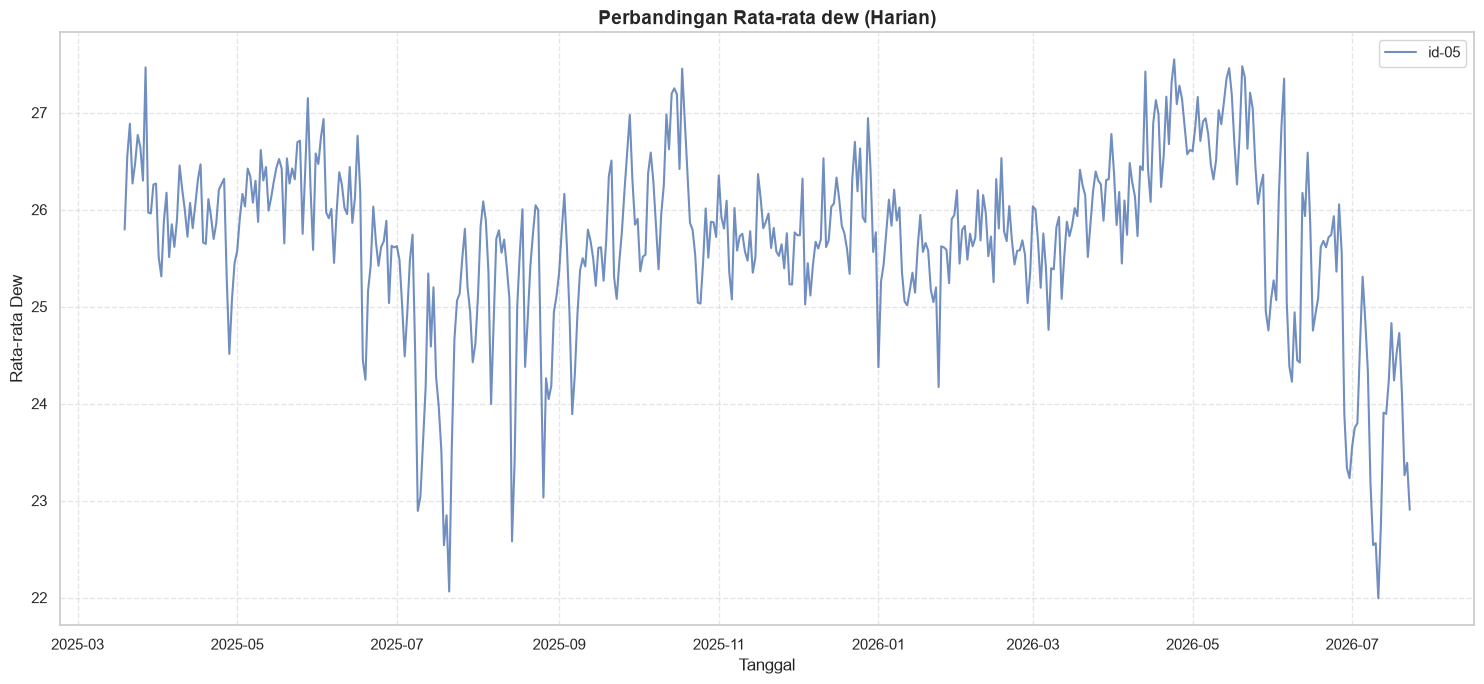

In [12]:
# --- 2. Membuat Plot Rata-rata PER HARI ---
# Gunakan nilai default freq='d' atau tulis secara eksplisit
print("\nMenampilkan plot perbandingan per hari...")
plot_station_trends(all_weather_dataframes, 'temperature', freq='d', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'humidity', freq='d', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'pressure', freq='d', agg_method='mean')
plot_station_trends(all_weather_dataframes, 'dew', freq='d', agg_method='mean')

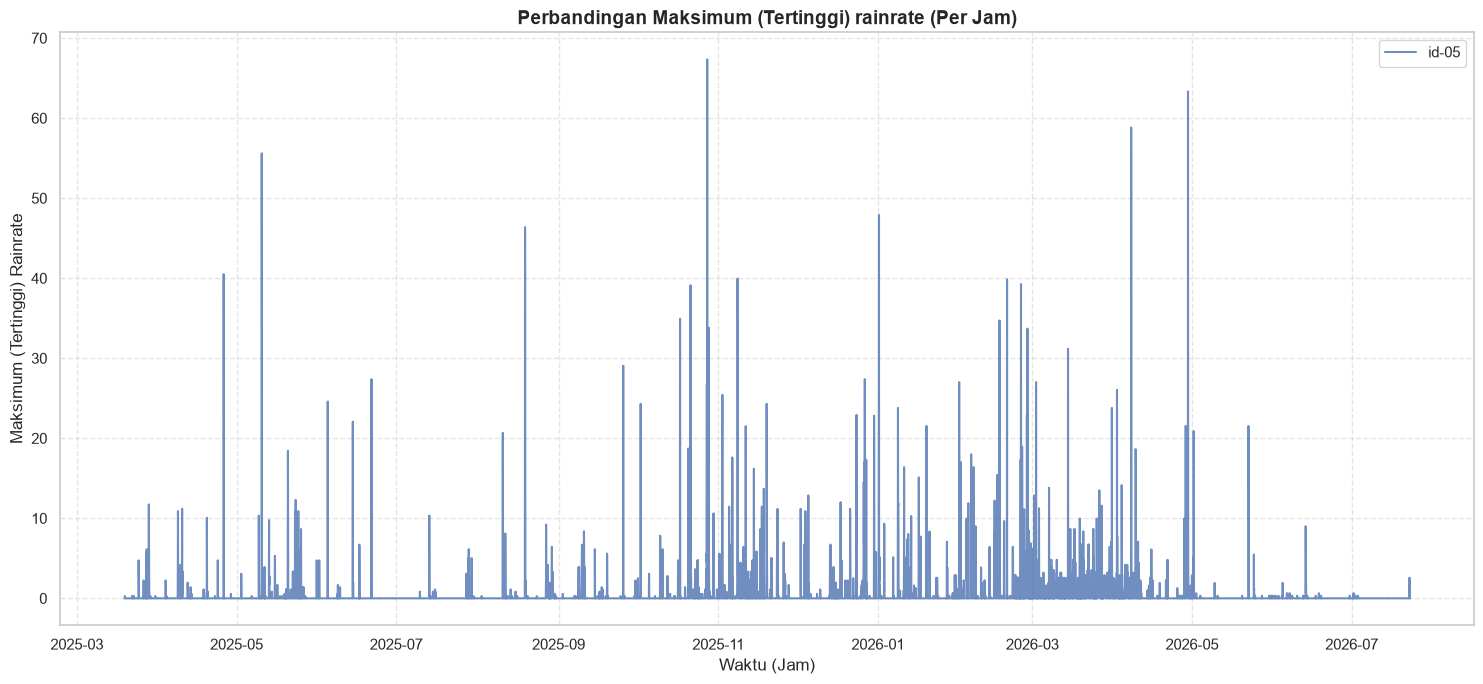

In [13]:
# 

plot_station_trends(all_weather_dataframes, 'rainrate', freq='h', agg_method='max')

In [14]:
cuaca5 = all_weather_dataframes['id-05']

In [15]:
cuaca5.tail(20)

,dew,humidity,pressure,rainfall,rainrate,temperature,volt,tips
timestamp,,,,,,,,
2026-07-23 03:52:26+00:00,23.44794,70.57549,1014.82,2.572,0.0,29.36866,3.97000,0.0
2026-07-23 03:53:26+00:00,23.28759,69.90791,1014.83,2.572,0.0,29.36599,3.97375,0.0
2026-07-23 03:54:26+00:00,23.41541,70.19974,1014.75,2.572,0.0,29.42741,3.98500,0.0
2026-07-23 03:55:26+00:00,23.78253,71.54635,1014.76,2.572,0.0,29.48081,3.96875,0.0
2026-07-23 03:56:26+00:00,23.49364,70.07767,1014.69,2.572,0.0,29.53956,3.99125,0.0
2026-07-23 03:57:26+00:00,23.42500,69.83161,1014.67,2.572,0.0,29.52888,3.96375,0.0
2026-07-23 03:58:26+00:00,23.45986,69.86022,1014.63,2.572,0.0,29.55825,3.96250,0.0
2026-07-23 03:59:26+00:00,23.38826,69.31471,1014.67,2.572,0.0,29.61967,3.96125,0.0
2026-07-23 04:00:26+00:00,23.53533,69.63134,1014.61,2.572,0.0,29.69444,3.98250,0.0


In [16]:
import pandas as pd
import numpy as np

# =======================================================
# 1. PERSIAPAN DATA WAKTU (PENTING!)
# =======================================================
# Kita gunakan IF agar aman. Jika kolom 'timestamp' masih ada, 
# kita jadikan dia DatetimeIndex. Jika sudah jadi index, kode ini diabaikan.
if 'timestamp' in cuaca5.columns:
    cuaca5['timestamp'] = pd.to_datetime(cuaca5['timestamp'])
    cuaca5 = cuaca5.sort_values('timestamp').set_index('timestamp')

# =======================================================
# 2. DETEKSI INCREMENT & PENANGANAN RESET ALAT
# =======================================================
# Hitung selisih hujan dari menit ke menit
cuaca5['delta_raw'] = cuaca5['rainrate'].diff()

# Jika negatif (reset), ambil nilai aslinya. Jika positif, ambil selisihnya.
cuaca5['actual_increment'] = np.where(
    cuaca5['delta_raw'] < 0, 
    cuaca5['rainrate'],      
    cuaca5['delta_raw']      
)
cuaca5['actual_increment'] = cuaca5['actual_increment'].fillna(0).clip(lower=0)

# =======================================================
# 3. FILTER OUTLIER (HARD PHYSICAL THRESHOLD)
# =======================================================
BATAS_MAKSIMAL_PER_MENIT = 1.15 # Konservatif untuk menghindari false positive

# Cari indeks mana yang tidak wajar
kondisi_outlier = cuaca5['actual_increment'] > BATAS_MAKSIMAL_PER_MENIT
jumlah_outlier = kondisi_outlier.sum()

print(f"ALERT: Terdeteksi {jumlah_outlier} titik outlier (goyangan palsu / lonjakan tak wajar)!")

# HANCURKAN OUTLIER
cuaca5.loc[kondisi_outlier, 'actual_increment'] = 0.0

# =======================================================
# 4. PEMBULATAN TIP (STANDARISASI KE 0.3)
# =======================================================
KONSTANTA_TIP = 0.3215
cuaca5['tips_count'] = np.round(cuaca5['actual_increment'] / KONSTANTA_TIP)
cuaca5['increment_fixed'] = cuaca5['tips_count'] * KONSTANTA_TIP

# =======================================================
# 5. REKONSTRUKSI AKUMULASI PER JAM
# =======================================================
# [DIPERBAIKI] Gunakan 'rainrate_fixed' agar data asli 'rainrate' tidak hilang!
# [DIPERBAIKI] Gunakan 'H' besar.
cuaca5['rainrate'] = cuaca5.groupby(cuaca5.index.floor('h'))['increment_fixed'].cumsum()

# =======================================================
# 6. AGREGASI HARIAN / PER JAM
# =======================================================
# [DIPERBAIKI] Resample menggunakan 'H' besar dan ambil kolom 'rainrate'
df_hourly = cuaca5.resample('h').agg({
    'rainrate': 'max',  # Mengambil nilai puncak akumulasi di jam tersebut
    'temperature': 'mean',    
    'humidity': 'mean',       
    'pressure': 'mean',       
    'dew': 'mean'             
})

# Tampilkan hasil
print("OK: Pembersihan dan Agregasi Selesai!")
print(df_hourly.head(10))

ALERT: Terdeteksi 960 titik outlier (goyangan palsu / lonjakan tak wajar)!
OK: Pembersihan dan Agregasi Selesai!
                           rainrate  temperature   humidity     pressure  \
timestamp                                                                  
2025-03-19 06:00:00+00:00    0.0000    28.163365  94.335827  1011.120959   
2025-03-19 07:00:00+00:00    0.3215    29.084335  91.649419  1010.880125   
2025-03-19 08:00:00+00:00    0.0000    30.934129  83.867371  1010.835198   
2025-03-19 09:00:00+00:00    0.0000    30.897955  83.783592  1010.911521   
2025-03-19 10:00:00+00:00    0.0000    28.565734  90.632079  1011.434678   
2025-03-19 11:00:00+00:00    0.0000    27.037647  94.918693  1011.847287   
2025-03-19 12:00:00+00:00    0.0000    26.603566  96.829447  1012.464685   
2025-03-19 13:00:00+00:00    0.0000    26.311772  97.622218  1013.006779   
2025-03-19 14:00:00+00:00    0.0000    26.173208  98.185907  1013.179163   
2025-03-19 15:00:00+00:00    0.0000    25.865855  9

C:\Users\acer\AppData\Local\Temp\ipykernel_9420\2073422007.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


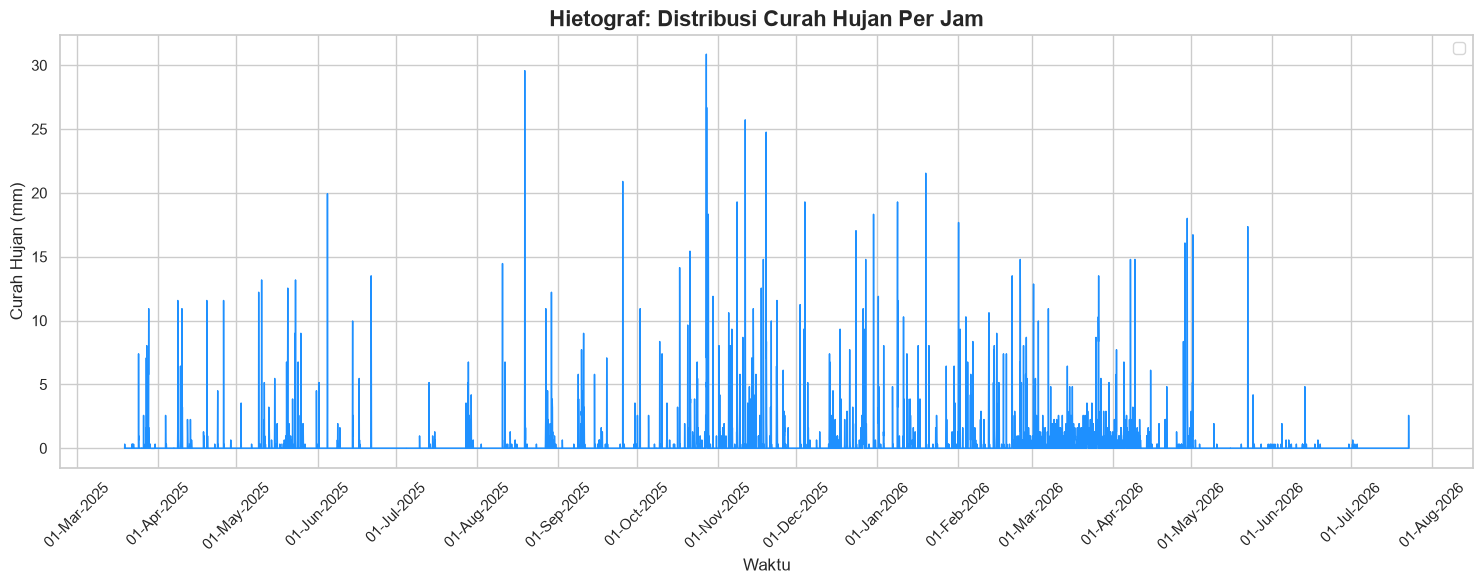

In [17]:
# Set Style biar ganteng
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 6))

# Alternatif kalau data sangat padat (tahunan), pakai ini:
plt.plot(df_hourly.index, df_hourly['rainrate'], color='dodgerblue', lw=1)
plt.fill_between(df_hourly.index, df_hourly['rainrate'], color='dodgerblue', alpha=0.3)

# B. PERCANTIK
plt.title('Hietograf: Distribusi Curah Hujan Per Jam', fontsize=16, fontweight='bold')
plt.ylabel('Curah Hujan (mm)', fontsize=12)
plt.xlabel('Waktu', fontsize=12)
plt.legend(loc='upper right')

# Format Tanggal di Sumbu X biar rapi
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator()) # Label per bulan
plt.xticks(rotation=45)

# Batas Y (opsional, biar kelihatan ruang atasnya)
# plt.ylim(0, df_hourly['rain'].max() * 1.2) 

plt.tight_layout()
plt.show()

In [18]:
df_hourly.tail(50)

,rainrate,temperature,humidity,pressure,dew
timestamp,,,,,
2026-07-21 03:00:00+00:00,0.000,30.167176,70.341393,1015.250333,24.153362
2026-07-21 04:00:00+00:00,0.000,30.632346,71.834362,1014.477667,24.951405
2026-07-21 05:00:00+00:00,0.000,30.814374,72.435567,1013.783333,25.266171
2026-07-21 06:00:00+00:00,0.000,31.194540,71.508073,1013.045667,25.414212
2026-07-21 07:00:00+00:00,0.000,31.226939,69.154462,1012.648167,24.880153
2026-07-21 08:00:00+00:00,0.000,30.753937,68.341825,1012.738500,24.231399
2026-07-21 09:00:00+00:00,0.000,28.757686,74.213117,1013.093667,23.690850
2026-07-21 10:00:00+00:00,0.000,27.204534,79.623968,1013.607667,23.363385
2026-07-21 11:00:00+00:00,0.000,26.224880,84.095276,1014.153167,23.316456


In [19]:
import matplotlib.pyplot as plt

def plot_komparasi(df_raw, df_clean, df_era5, era5_mapping, start_time, end_time):
    """
    Menampilkan perbandingan 3 lapis: ERA5 Asli vs IoT Mentah vs IoT Bersih
    Untuk membuktikan bahwa asimilasi data berjalan dengan jujur.
    """
    print(f"\n MEMUAT KOMPARASI TRANSPARANSI DATA: {start_time} s.d {end_time}")

    # Daftar variabel yang ingin diadu
    kolom_visual = ['temperature', 'humidity', 'pressure', 'dew', 'rainrate']

    # Potong data sesuai rentang waktu agar plot tidak terlalu padat
    df_raw_plot = df_raw.loc[start_time:end_time]
    df_clean_plot = df_clean.loc[start_time:end_time]
    df_era5_plot = df_era5.loc[start_time:end_time]

    for col in kolom_visual:
        plt.figure(figsize=(15, 5))

        # ---------------------------------------------------------
        # 1. PLOT ERA5 (Satelit) - Garis Hijau Putus-putus
        # ---------------------------------------------------------
        col_era5 = era5_mapping.get(col)
        # Khusus untuk rainrate, jika mappingnya rain, kita panggil itu
        if not col_era5 and col == 'rainrate': 
            col_era5 = era5_mapping.get('rainrate', 'rain')

        if col_era5 and col_era5 in df_era5_plot.columns:
            plt.plot(df_era5_plot.index, df_era5_plot[col_era5], 
                     color='green', linestyle=':', linewidth=2, alpha=0.7, 
                     label=f'ERA5 Data ({col_era5})')

        # ---------------------------------------------------------
        # 2. PLOT IoT MENTAH (Raw Data) - Titik Merah (Silang)
        # ---------------------------------------------------------
        if col in df_raw_plot.columns:
            # Menggunakan linestyle='None' agar hanya titik merah yang muncul.
            # Ini sangat bagus untuk melihat data yang aslinya bolong-bolong.
            plt.plot(df_raw_plot.index, df_raw_plot[col], 
                     color='red', marker='x', markersize=5, linestyle='None', alpha=0.6, 
                     label='Raw Data Sensor')

        # ---------------------------------------------------------
        # 3. PLOT IoT BERSIH (Imputasi) - Garis Biru Solid
        # ---------------------------------------------------------
        if col in df_clean_plot.columns:
            plt.plot(df_clean_plot.index, df_clean_plot[col], 
                     color='yellow', linewidth=1, alpha=0.9, 
                     label='Clean Data (Imputasi PCHIP + ERA5)')

        # ---------------------------------------------------------
        # KOSMETIK GRAFIK
        # ---------------------------------------------------------
        plt.title(f'Sidik Jari Asimilasi Data: {col.upper()}', fontsize=14, fontweight='bold')
        plt.ylabel(f'Nilai {col.capitalize()}', fontsize=12)
        plt.xlabel('Waktu', fontsize=12)
        plt.legend(fontsize=11, loc='best')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

# ==============================================================================
# CARA EKSEKUSI:
# ==============================================================================
# Pastikan Anda menggunakan rentang waktu yang agak pendek agar detailnya terlihat jelas
# start_uji = '2026-03-01 00:00:00'
# end_uji = '2026-03-15 23:59:59'

# plot_komparasi(df_raw_03, df_clean_03, df_era5, era5_mapping, start_uji, end_uji)


def plot_sebelum_sesudah(df_raw, df_clean, kolom, satuan, start_time, end_time):
    """
    Menampilkan perbandingan dua panel (Before vs After) untuk satu variabel:
    - Panel Kiri (SEBELUM): Data Mentah dengan gap/NaN divisualisasikan
    - Panel Kanan (SESUDAH): Data Bersih setelah imputasi

    Parameters:
        df_raw      : DataFrame raw (sebelum imputasi, bisa ada NaN)
        df_clean    : DataFrame bersih (sesudah imputasi)
        kolom       : nama kolom yang ingin divisualisasikan, misal 'temperature'
        satuan      : satuan pengukuran untuk label Y-axis, misal 'Celcius'
        start_time  : string waktu mulai, misal '2025-01-01 00:00:00'
        end_time    : string waktu akhir, misal '2026-05-31 23:59:59'
    """
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    import pandas as pd
    import numpy as np
    import matplotlib.patches as mpatches

    if kolom not in df_raw.columns and kolom not in df_clean.columns:
        print(f"[WARNING] Kolom '{kolom}' tidak ditemukan di kedua DataFrame. Melewati plot.")
        return

    # ---- Potong data sesuai rentang waktu ----
    df_raw_plot = df_raw.loc[start_time:end_time].copy() if kolom in df_raw.columns else pd.DataFrame()
    df_clean_plot = df_clean.loc[start_time:end_time].copy() if kolom in df_clean.columns else pd.DataFrame()

    # ---- Hitung statistik gap ----
    total_jam = len(df_clean_plot) if not df_clean_plot.empty else 0
    jml_gap_raw = int(df_raw_plot[kolom].isna().sum()) if not df_raw_plot.empty else 0
    jml_gap_clean = int(df_clean_plot[kolom].isna().sum()) if not df_clean_plot.empty else 0
    persen_gap_raw = (jml_gap_raw / total_jam * 100) if total_jam > 0 else 0

    # ---- Buat figure dengan 2 subplot (side by side) ----
    fig, axes = plt.subplots(1, 2, figsize=(22, 6), sharey=True)
    fig.suptitle(
        f'Komparasi Sebelum vs Sesudah Imputasi: {kolom.upper()}\n'
        f'Periode: {start_time} s.d. {end_time}',
        fontsize=14, fontweight='bold', y=1.02
    )

    # ========================================================
    # PANEL KIRI: DATA MENTAH (SEBELUM IMPUTASI)
    # ========================================================
    ax_left = axes[0]
    if not df_raw_plot.empty and kolom in df_raw_plot.columns:
        # Plot data valid (non-NaN) sebagai garis biru
        valid_mask = df_raw_plot[kolom].notna()
        ax_left.plot(
            df_raw_plot.index[valid_mask],
            df_raw_plot[kolom][valid_mask],
            color='steelblue', linewidth=0.8, alpha=0.85, label='Data Valid (Sensor Aktif)'
        )

        # Arsir area gap (NaN) dengan warna merah transparan
        nan_mask = df_raw_plot[kolom].isna()
        if nan_mask.any():
            in_gap = False
            gap_start = None
            for ts, is_nan in nan_mask.items():
                if is_nan and not in_gap:
                    gap_start = ts
                    in_gap = True
                elif not is_nan and in_gap:
                    ax_left.axvspan(gap_start, ts, color='red', alpha=0.25, label='_nolegend_')
                    in_gap = False
            if in_gap:  # Gap sampai akhir
                ax_left.axvspan(gap_start, df_raw_plot.index[-1], color='red', alpha=0.25)

        gap_patch = mpatches.Patch(color='red', alpha=0.35, label=f'Data Hilang / Gap ({jml_gap_raw:,} jam | {persen_gap_raw:.1f}%)')
        valid_line = plt.Line2D([0], [0], color='steelblue', linewidth=1.5, label=f'Data Valid ({total_jam - jml_gap_raw:,} jam)')
        ax_left.legend(handles=[valid_line, gap_patch], fontsize=10, loc='best')

    ax_left.set_title(f'SEBELUM Imputasi\nGap: {jml_gap_raw:,} jam dari {total_jam:,} jam ({persen_gap_raw:.1f}%)', fontsize=12, color='crimson')
    ax_left.set_ylabel(f'{kolom.capitalize()} ({satuan})', fontsize=11)
    ax_left.set_xlabel('Waktu (UTC)', fontsize=11)
    ax_left.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax_left.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax_left.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax_left.grid(True, linestyle='--', alpha=0.4)

    # ========================================================
    # PANEL KANAN: DATA BERSIH (SESUDAH IMPUTASI)
    # ========================================================
    ax_right = axes[1]
    if not df_clean_plot.empty and kolom in df_clean_plot.columns:
        qc_col = f'is_imputed_{kolom}'
        if qc_col in df_clean_plot.columns:
            mask_original = df_clean_plot[qc_col] == 0
            mask_imputed = df_clean_plot[qc_col] == 1

            ax_right.plot(
                df_clean_plot.index[mask_original],
                df_clean_plot[kolom][mask_original],
                color='steelblue', linewidth=0.8, alpha=0.85, label='Data Asli Sensor'
            )
            ax_right.plot(
                df_clean_plot.index[mask_imputed],
                df_clean_plot[kolom][mask_imputed],
                color='darkorange', linewidth=0.9, alpha=0.9, label='Data Imputasi (PCHIP/ERA5)'
            )
        else:
            ax_right.plot(
                df_clean_plot.index,
                df_clean_plot[kolom],
                color='steelblue', linewidth=0.8, alpha=0.85, label='Data Bersih'
            )

        persen_gap_clean = (jml_gap_clean / total_jam * 100) if total_jam > 0 else 0
        ax_right.set_title(
            f'SESUDAH Imputasi\nGap Sisa: {jml_gap_clean:,} jam dari {total_jam:,} jam ({persen_gap_clean:.1f}%)',
            fontsize=12, color='darkgreen'
        )
        ax_right.legend(fontsize=10, loc='best')

    ax_right.set_xlabel('Waktu (UTC)', fontsize=11)
    ax_right.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax_right.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax_right.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax_right.grid(True, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()
    print(f"[OK] Plot sebelum/sesudah untuk '{kolom}' berhasil ditampilkan.")


In [20]:
def save_hourly_clean_dataset(df_clean, station_id, output_folder='clear data'):
    """
    Formats, validates, and exports the hourly meteorological dataset according to strict schemas.
    """
    os.makedirs(output_folder, exist_ok=True)
    
    df_final = df_clean.copy()
    
    # Standardize dewpoint name
    if 'dew' in df_final.columns:
        df_final = df_final.rename(columns={'dew': 'dewpoint'})
        
    if not isinstance(df_final.index, pd.DatetimeIndex):
        df_final.index = pd.to_datetime(df_final.index)
        
    # Build strict columns
    # Cast to datetime64[ns] strictly to ensure unixtime is in seconds regardless of internal pandas unit (Pandas 2.0+ support)
    if df_final.index.tz is not None:
        df_final['unixtime'] = df_final.index.astype('datetime64[ns, UTC]').astype('int64') // 10**9
    else:
        df_final['unixtime'] = df_final.index.astype('datetime64[ns]').astype('int64') // 10**9
    df_final['datetime_utc'] = df_final.index.strftime('%Y-%m-%d %H:%M:%S')
    
    # Ensure all required columns exist
    kolom_wajib = ['datetime_utc', 'unixtime', 'temperature', 'humidity', 'pressure', 'dewpoint', 'rainrate']
    for col in kolom_wajib:
        if col not in df_final.columns:
            df_final[col] = float('nan')
            
    # Reorder columns EXACTLY as requested
    df_final = df_final[kolom_wajib]
    
    # ---------------------------
    # DATA VALIDATION CHECKS
    # ---------------------------
    
    # Datetime Validation
    jml_duplikat = df_final.index.duplicated().sum()
    is_monotonic = df_final.index.is_monotonic_increasing
    start_dt = df_final.index.min()
    end_dt = df_final.index.max()
    
    expected_hours = int((end_dt - start_dt).total_seconds() // 3600) + 1 if pd.notnull(start_dt) else 0
    actual_hours = len(df_final)
    missing_hours = expected_hours - actual_hours if expected_hours > 0 else 0
    
    invalid_dt = df_final['datetime_utc'].isnull().sum()
    invalid_unix = df_final['unixtime'].isnull().sum()
    
    # Numeric Validation
    numeric_cols = ['temperature', 'humidity', 'pressure', 'dewpoint', 'rainrate']
    nan_counts = df_final[numeric_cols].isna().sum().to_dict()
    inf_counts = np.isinf(df_final[numeric_cols]).sum().to_dict()
    
    temp_valid = df_final['temperature'].between(-10, 60) | df_final['temperature'].isna()
    hum_valid = df_final['humidity'].between(0, 100) | df_final['humidity'].isna()
    pres_valid = df_final['pressure'].between(850, 1100) | df_final['pressure'].isna()
    dew_valid = df_final['dewpoint'].between(-20, 60) | df_final['dewpoint'].isna()
    
    temp_outbounds = (~temp_valid).sum()
    hum_outbounds = (~hum_valid).sum()
    pres_outbounds = (~pres_valid).sum()
    dew_outbounds = (~dew_valid).sum()
    
    # Output csv
    output_path = os.path.join(output_folder, f"{station_id}_clear_data_hourly.csv")
    
    df_export = df_final.reset_index(drop=True)
    df_export.to_csv(output_path, index=False)
    
    report_md = f"""###  Hourly Dataset Summary & Validation Results: `{station_id}`
#### Output Files Generated
- **CSV Export:** `{output_path}`
- **Total Records:** `{actual_hours:,}`
- **Time Range:** `{start_dt}` to `{end_dt}`
#### Datetime Validation
- **Missing Timestamps (Hours):** `{missing_hours}`
- **Duplicate Timestamps:** `{jml_duplikat}`
- **Chronological Ordering Verified:** `{'Yes' if is_monotonic else 'No'}`
- **Invalid Datetime Values:** `{invalid_dt}`
- **Invalid Unix Timestamps:** `{invalid_unix}`
#### Numeric & Meteorological Validation
| Metric | NaN Count | Infinity Count | Out of Bounds Count |
|--------|-----------|----------------|---------------------|
| Temperature | {nan_counts['temperature']} | {inf_counts['temperature']} | {temp_outbounds} |
| Humidity | {nan_counts['humidity']} | {inf_counts['humidity']} | {hum_outbounds} |
| Pressure | {nan_counts['pressure']} | {inf_counts['pressure']} | {pres_outbounds} |
| Dewpoint | {nan_counts['dewpoint']} | {inf_counts['dewpoint']} | {dew_outbounds} |
| Rainrate | {nan_counts['rainrate']} | {inf_counts['rainrate']} | 0 |
"""
    display(Markdown(report_md))
    return output_path


In [21]:
def agregasi_dan_bersihkan_hujan(df):
    import pandas as pd
    import numpy as np
    temp_df = df.copy()
    if 'timestamp' in temp_df.columns:
        temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])
        temp_df = temp_df.sort_values('timestamp').set_index('timestamp')
    # Standardize column name to 'dew' to match the pipeline's expected kolom_sensor
    if 'dewpoint' in temp_df.columns:
        temp_df = temp_df.rename(columns={'dewpoint': 'dew'})
    # 1. Deteksi Increment & Penanganan Reset
    if 'rainrate' in temp_df.columns:
        delta = temp_df['rainrate'].diff().fillna(0)
        increment = np.where(delta < 0, temp_df['rainrate'], delta)
        
        # 2. Filter Outlier & Clip Negatif
        increment = np.where(increment > 3.0, 0.0, increment)
        increment = np.clip(increment, 0, None)
        
        # 3. Kuantisasi kelipatan 0.3 (Pembulatan Tip Tipping Bucket)
        temp_df['rainrate'] = np.round(increment / 0.3) * 0.3
    # 4. Agregasi per Jam (Hujan dijumlahkan, parameter cuaca dirata-rata)
    agg_dict = {}
    if 'rainrate' in temp_df.columns: agg_dict['rainrate'] = 'sum'
    if 'temperature' in temp_df.columns: agg_dict['temperature'] = 'mean'
    if 'humidity' in temp_df.columns: agg_dict['humidity'] = 'mean'
    if 'pressure' in temp_df.columns: agg_dict['pressure'] = 'mean'
    if 'dew' in temp_df.columns: agg_dict['dew'] = 'mean'
    df_hourly = temp_df.resample('h').agg(agg_dict)
    return df_hourly
# ==============================================================================
# PROSES PEMBERSIHAN MULTI-STASIUN & EKSPOR
# ==============================================================================
import os
import numpy as np
output_folder = os.path.join(BASE_DIR, 'Google_Earth_Engine', 'Data_Satelit')
os.makedirs(output_folder, exist_ok=True)
from datetime import datetime
# Input readable date (menggunakan nilai global dari Sel 2 jika sudah di-run, fallback jika belum)
if 'start_readable_date' not in locals():
    start_readable_date = "01-01-2025 00:00:00"  # Format: DD-MM-YYYY HH:MM:SS
if 'end_readable_date' not in locals():
    end_readable_date = "13-07-2026 23:59:59"  # Format: DD-MM-YYYY HH:MM:SS
start_global = datetime.strptime(start_readable_date, "%d-%m-%Y %H:%M:%S").strftime('%Y-%m-%d %H:%M:%S')
end_global = datetime.strptime(end_readable_date, "%d-%m-%Y %H:%M:%S").strftime('%Y-%m-%d %H:%M:%S')
df_raw_05 = None
df_clean_05 = None
df_rain_median = load_multi_satellite_rain(start_global, end_global)
station_ids = ['id-05']
for station_id, df_raw in all_weather_dataframes.items():
    if station_id not in station_ids: 
        continue
    print(f"\n{'='*50}\n Memproses Stasiun: {station_id}")
    # A. Pra-Pemrosesan Agregasi & Hujan
    df_hourly = agregasi_dan_bersihkan_hujan(df_raw)
    # B. Asimilasi ERA5 dan Penambalan Imputasi Hibrida
    df_raw_reindexed, df_clean = bersihkan_data_hourly(df_hourly, df_era5, df_rain_median, start_global, end_global)
    if station_id == 'id-05':
        df_raw_05 = df_raw_reindexed
        df_clean_05 = df_clean
    # C. Validate and Export using new function
    output_path = save_hourly_clean_dataset(df_clean, station_id, output_folder)
    print(f" Tersimpan -> {output_path}")
    import gc
    try:
        del df_hourly
        del df_raw_reindexed
        del df_clean
    except NameError:
        pass
    gc.collect()
print("\n SELURUH PROSES SELESAI!")


[OK] Konsensus Hujan Satelit Siap (Nilai Maksimal Median: 24.37 mm)

 Memproses Stasiun: id-05
Memulai Pipeline Imputasi Hibrida | Rentang: 2025-01-01 00:00:00 s.d 2026-07-17 23:59:59
   -> [Bias Correction] TEMPERATURE : MBE =   +0.96 | MAE =  1.28
   -> [Bias Correction] HUMIDITY    : MBE =   +3.29 | MAE =  4.83
   -> [Bias Correction] PRESSURE    : MBE =   +1.28 | MAE =  1.28
   -> [Bias Correction] DEW         : MBE =   +1.57 | MAE =  1.60
   -> [Diurnal Correction] Mengoreksi bias radiasi untuk suhu, kelembaban, dan dewpoint siang hari...
   -> [Rainfall Injection] Menginjeksi data hujan dari Konsensus Satelit (Median)...
OK: Pipeline Selesai! Data sudah Terstandarisasi Mutlak dengan QC Flags.


###  Hourly Dataset Summary & Validation Results: `id-05`
#### Output Files Generated
- **CSV Export:** `d:\Github\Projek_Rainfall\Google_Earth_Engine\Data_Satelit\id-05_clear_data_hourly.csv`
- **Total Records:** `13,512`
- **Time Range:** `2025-01-01 00:00:00+00:00` to `2026-07-17 23:00:00+00:00`
#### Datetime Validation
- **Missing Timestamps (Hours):** `0`
- **Duplicate Timestamps:** `0`
- **Chronological Ordering Verified:** `Yes`
- **Invalid Datetime Values:** `0`
- **Invalid Unix Timestamps:** `0`
#### Numeric & Meteorological Validation
| Metric | NaN Count | Infinity Count | Out of Bounds Count |
|--------|-----------|----------------|---------------------|
| Temperature | 0 | 0 | 0 |
| Humidity | 0 | 0 | 0 |
| Pressure | 0 | 0 | 0 |
| Dewpoint | 0 | 0 | 0 |
| Rainrate | 0 | 0 | 0 |


 Tersimpan -> d:\Github\Projek_Rainfall\Google_Earth_Engine\Data_Satelit\id-05_clear_data_hourly.csv

 SELURUH PROSES SELESAI!



 MEMUAT KOMPARASI TRANSPARANSI DATA: 2025-01-01 00:00:00 s.d 2026-07-17 23:59:59


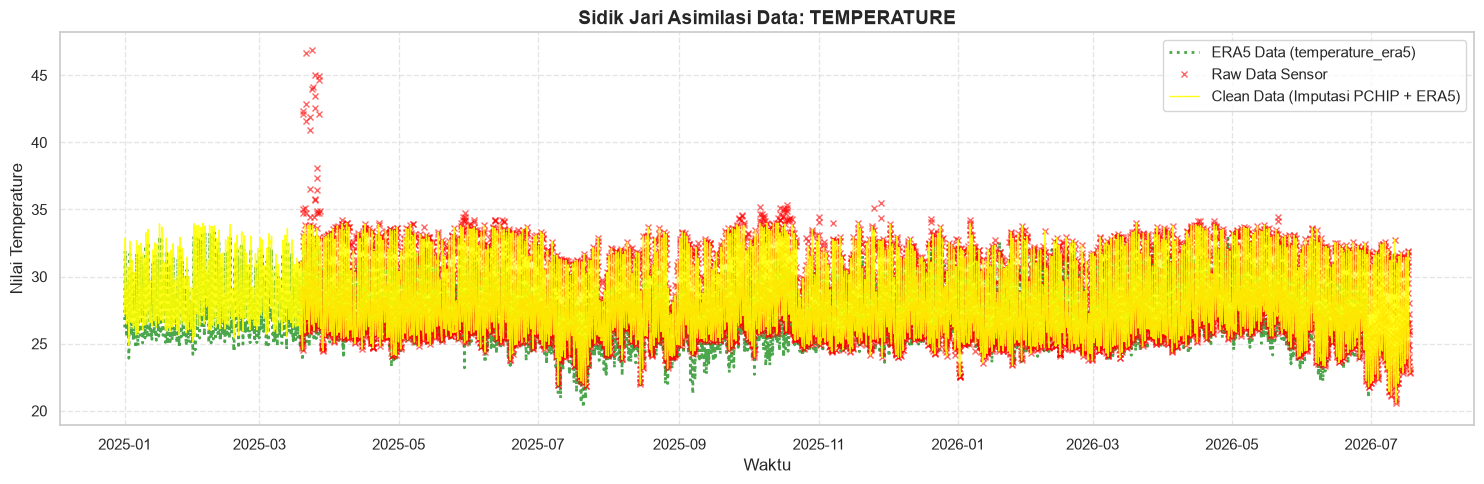

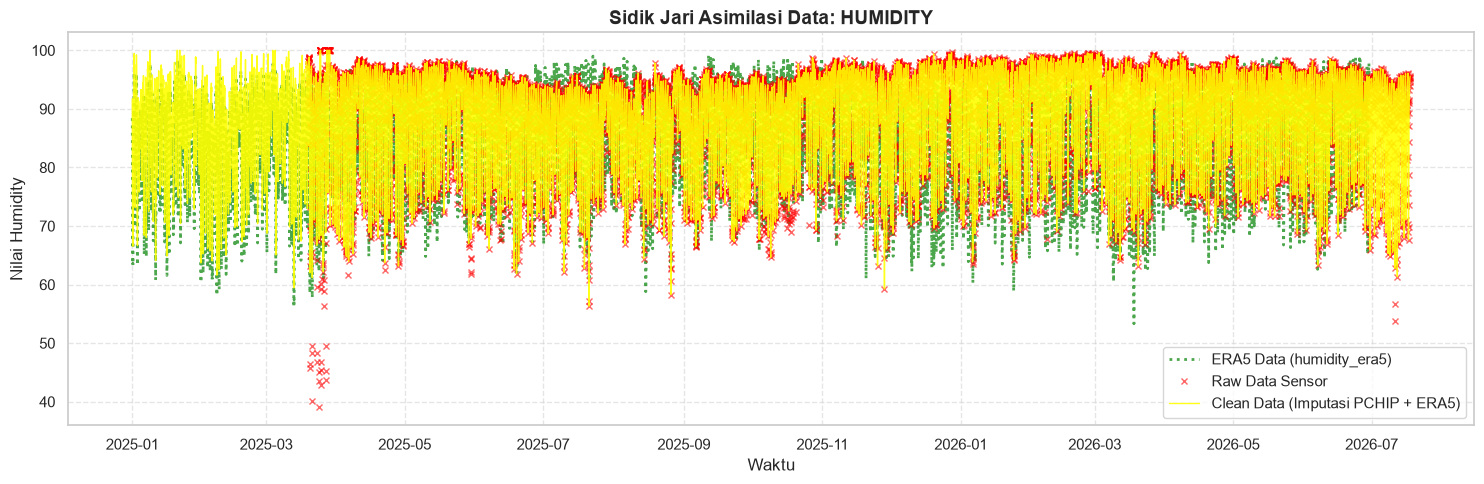

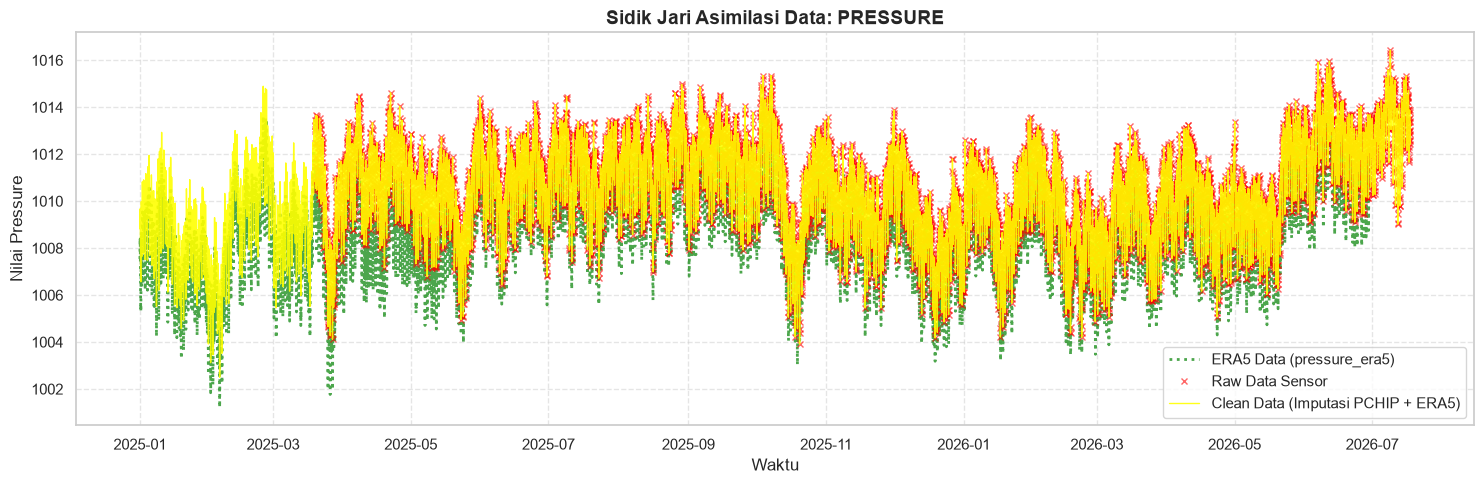

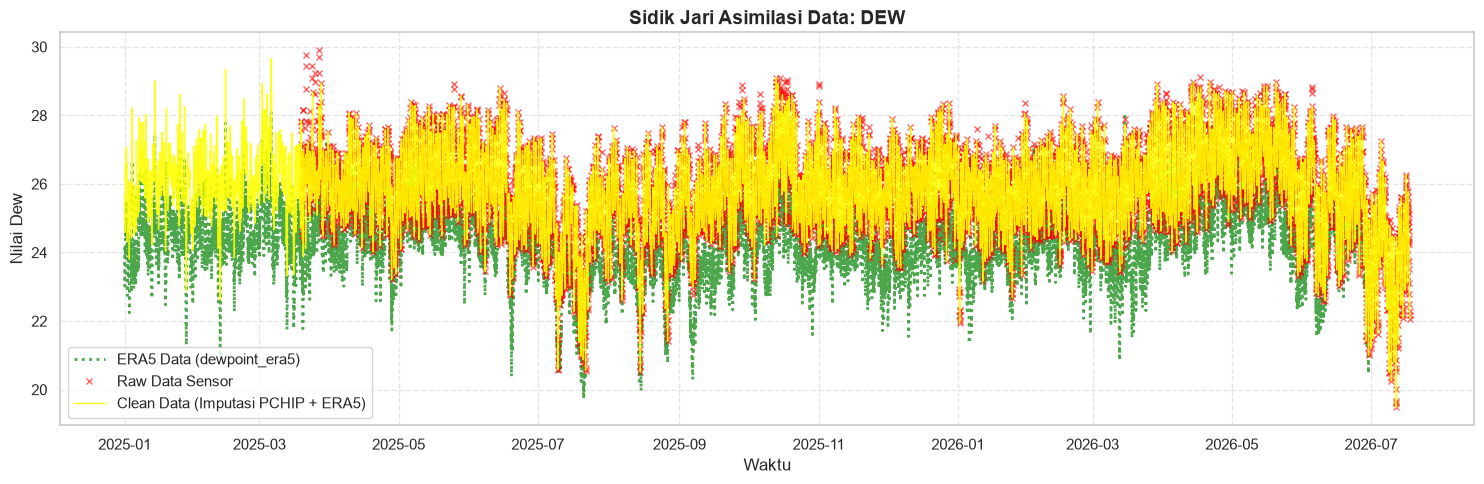

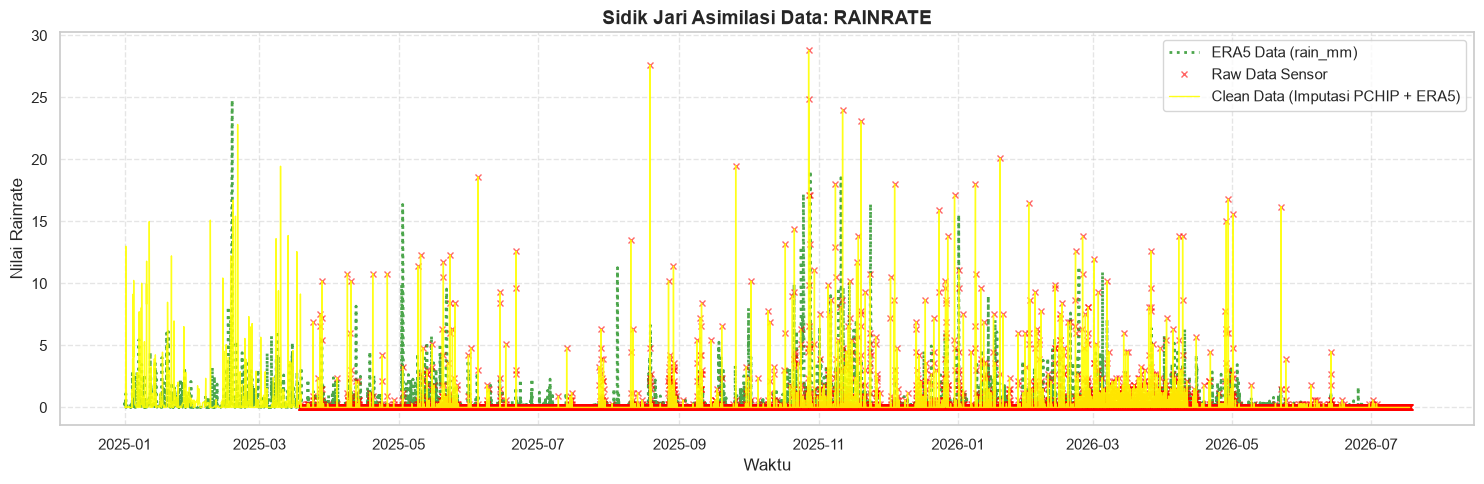

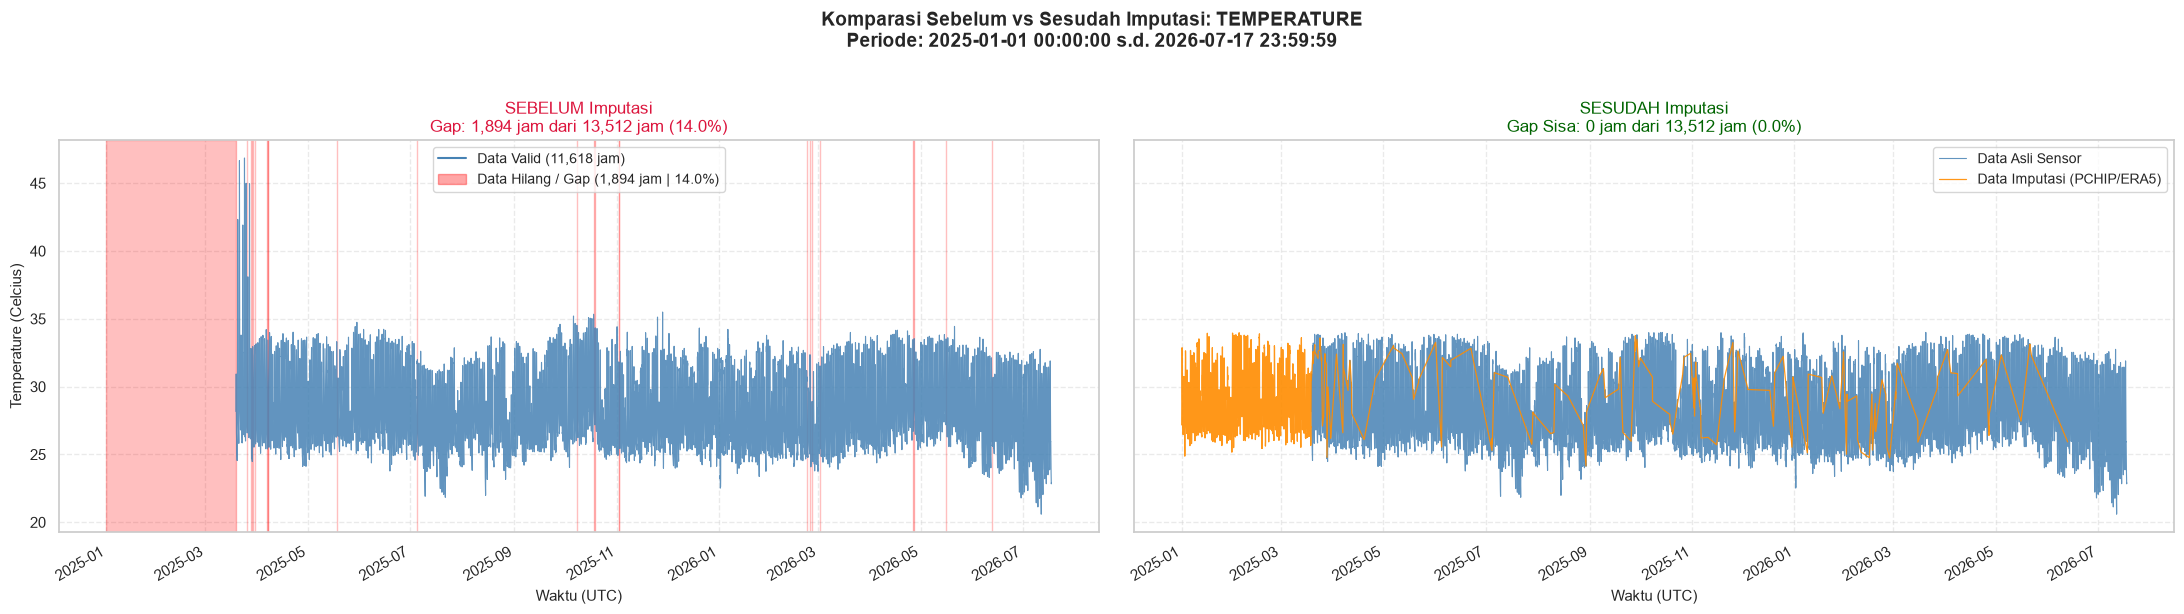

[OK] Plot sebelum/sesudah untuk 'temperature' berhasil ditampilkan.


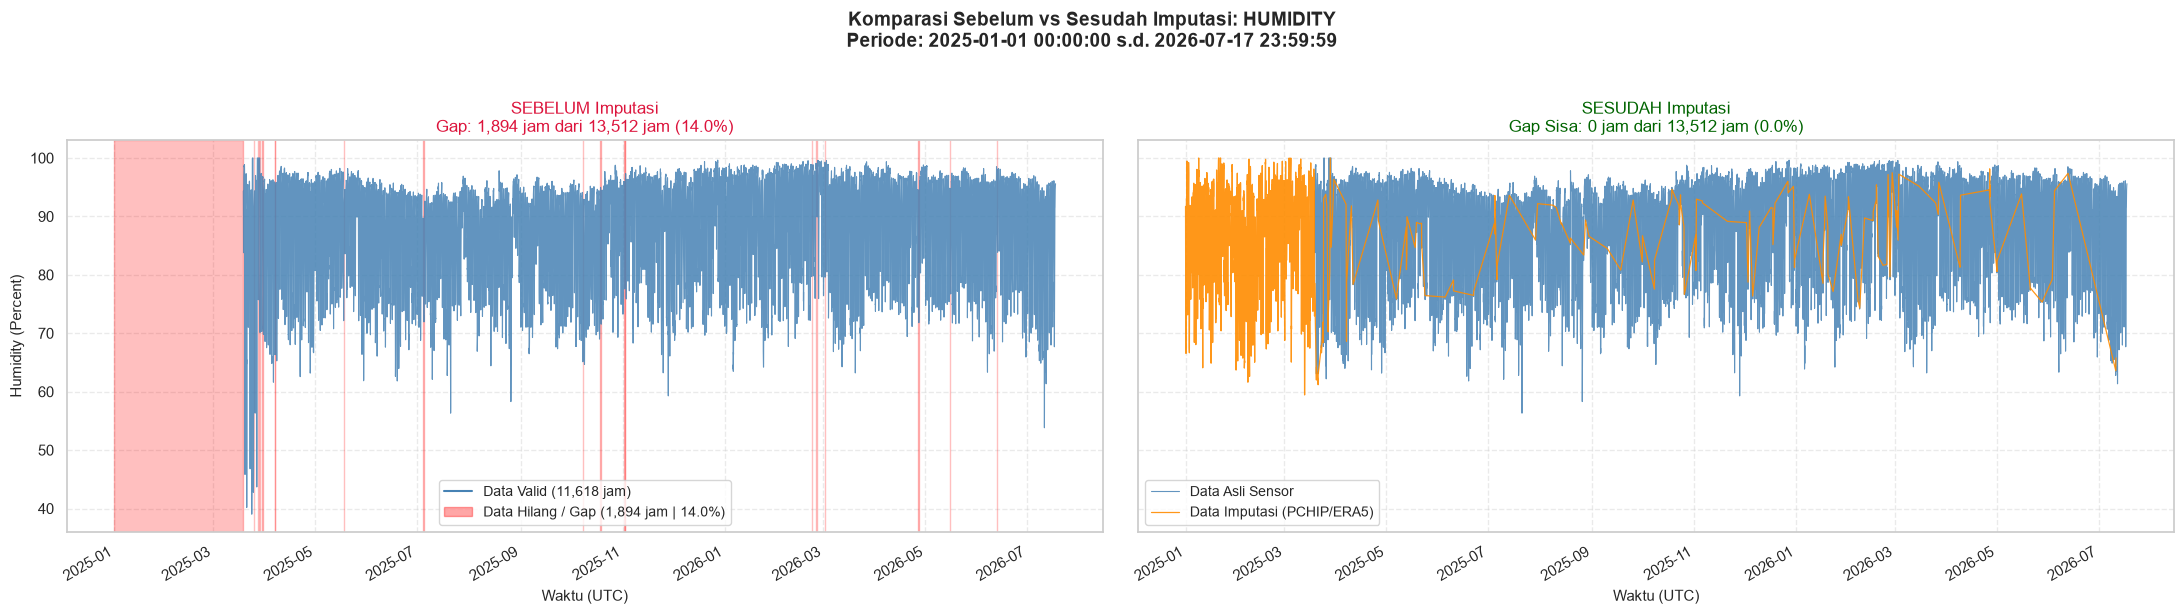

[OK] Plot sebelum/sesudah untuk 'humidity' berhasil ditampilkan.


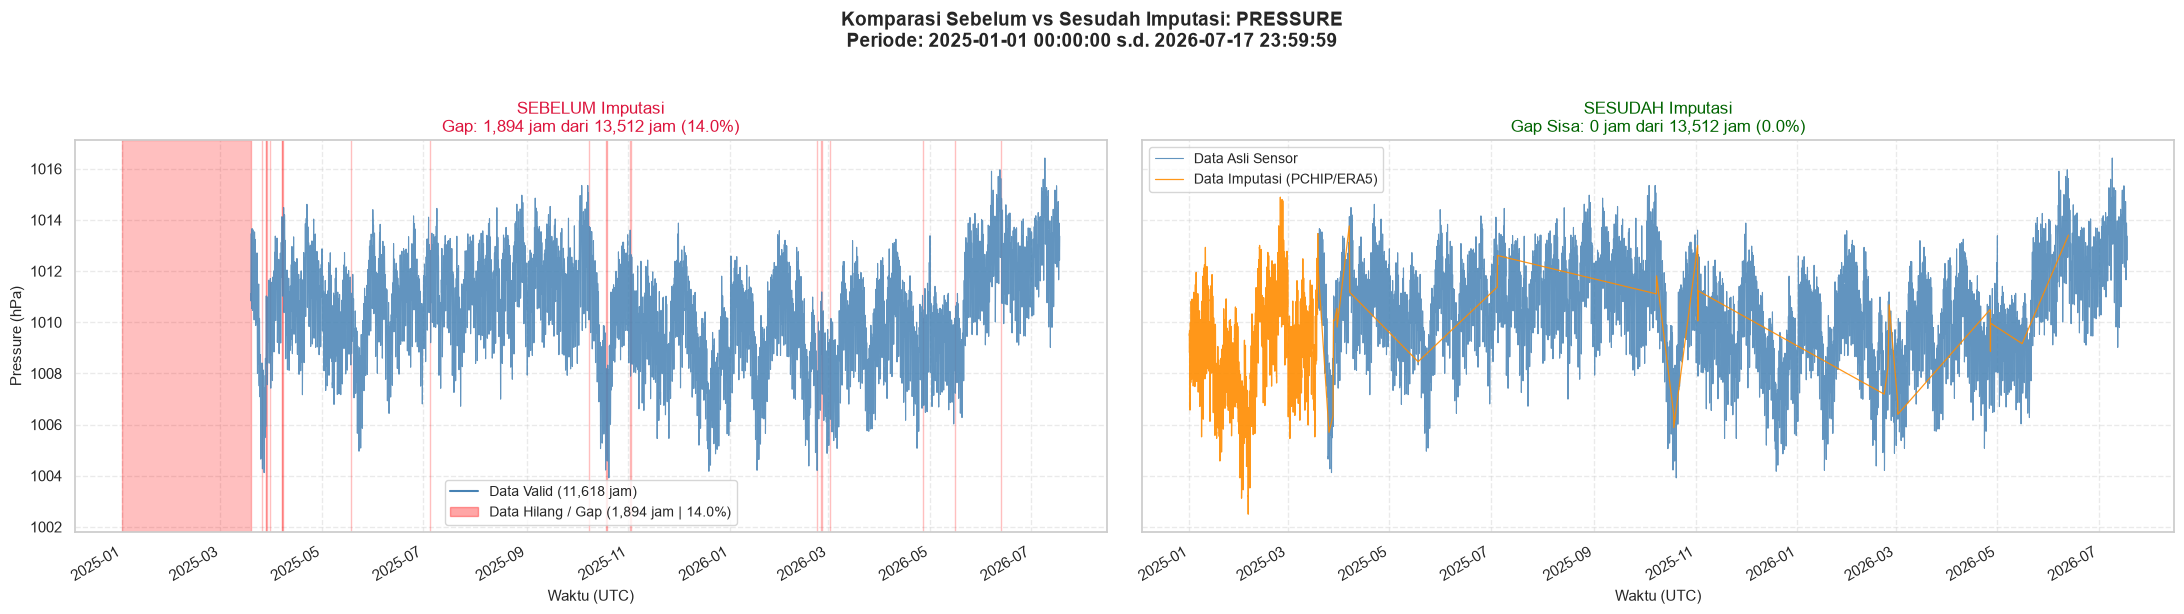

[OK] Plot sebelum/sesudah untuk 'pressure' berhasil ditampilkan.


In [22]:
start_uji = start_global
end_uji = end_global
# 
plot_komparasi(df_raw_05, df_clean_05, df_era5, era5_mapping, start_uji, end_uji)
plot_sebelum_sesudah(df_raw_05, df_clean_05, 'temperature', 'Celcius', start_uji, end_uji)
plot_sebelum_sesudah(df_raw_05, df_clean_05, 'humidity', 'Percent', start_uji, end_uji)
plot_sebelum_sesudah(df_raw_05, df_clean_05, 'pressure', 'hPa', start_uji, end_uji)

 MENGHITUNG MATRIKS KORELASI UNTUK: TEMPERATURE
 MENGHITUNG MATRIKS KORELASI UNTUK: HUMIDITY
 MENGHITUNG MATRIKS KORELASI UNTUK: PRESSURE
 MENGHITUNG MATRIKS KORELASI UNTUK: DEW
 MENGHITUNG MATRIKS KORELASI UNTUK: RAINRATE


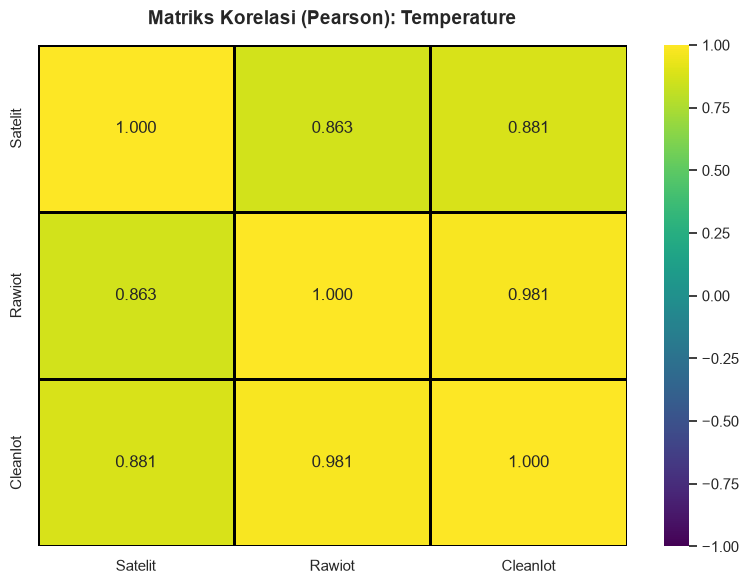

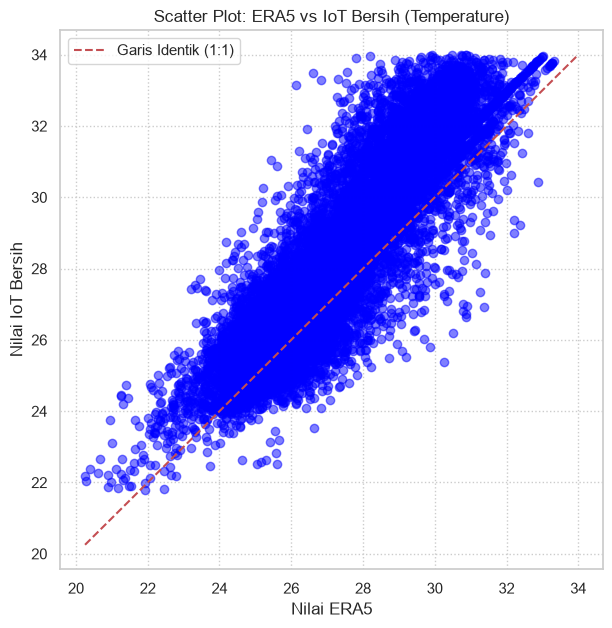

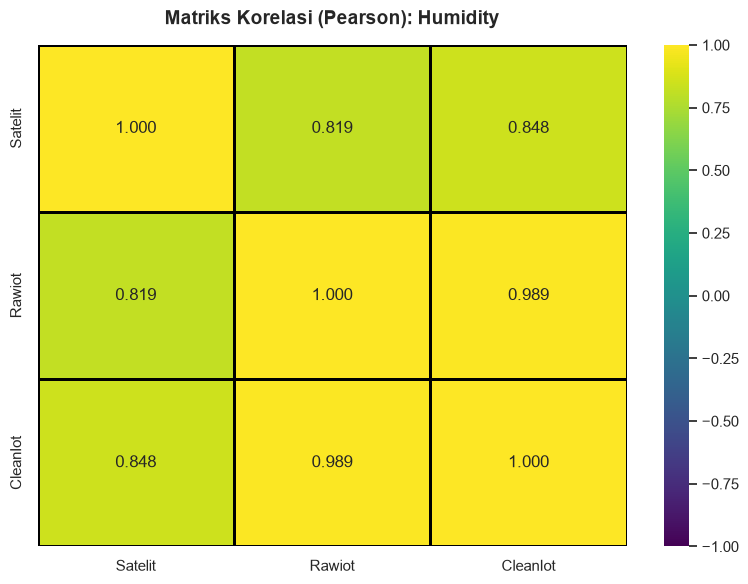

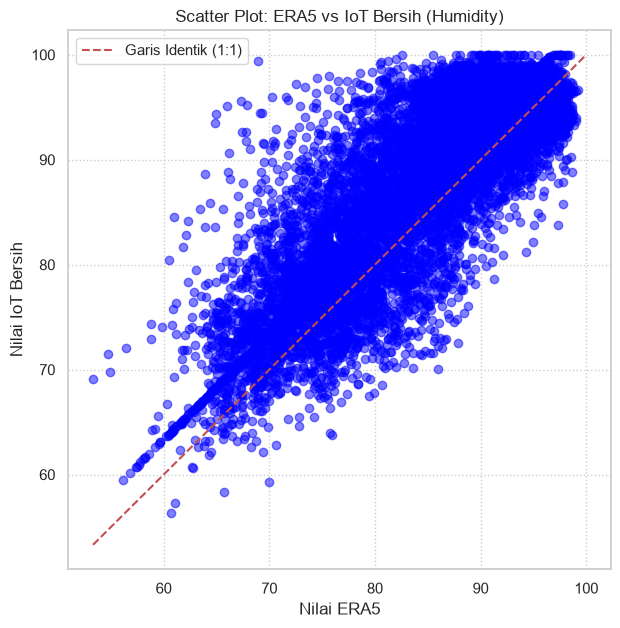

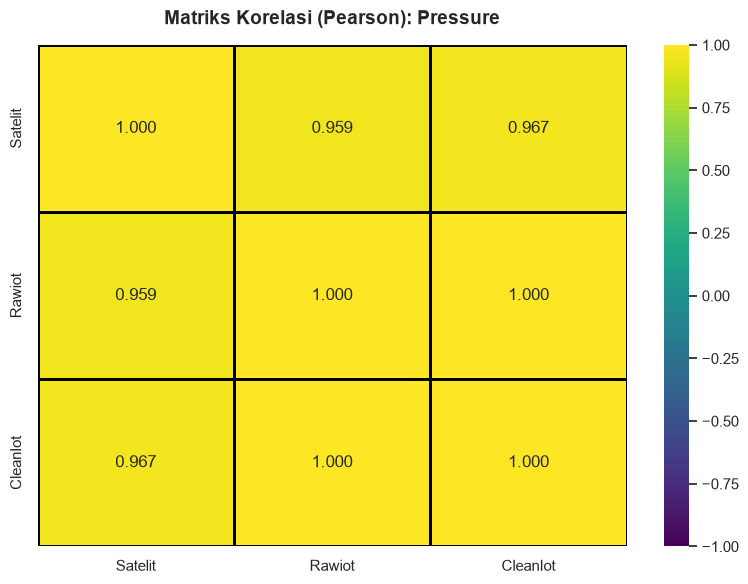

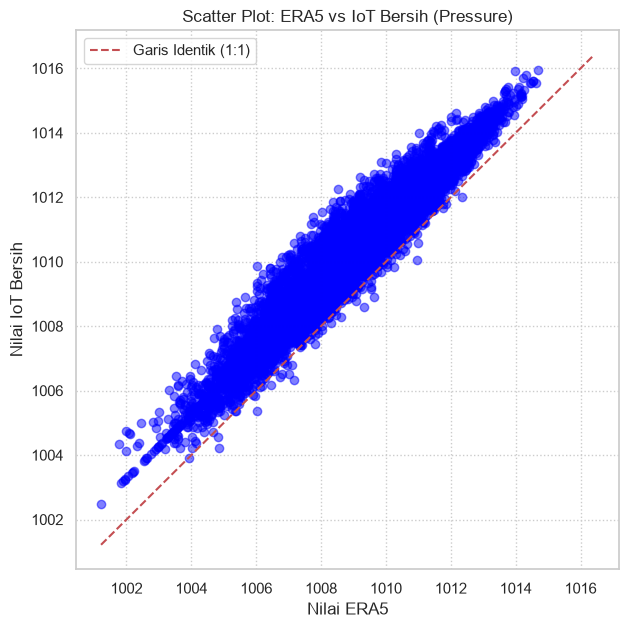

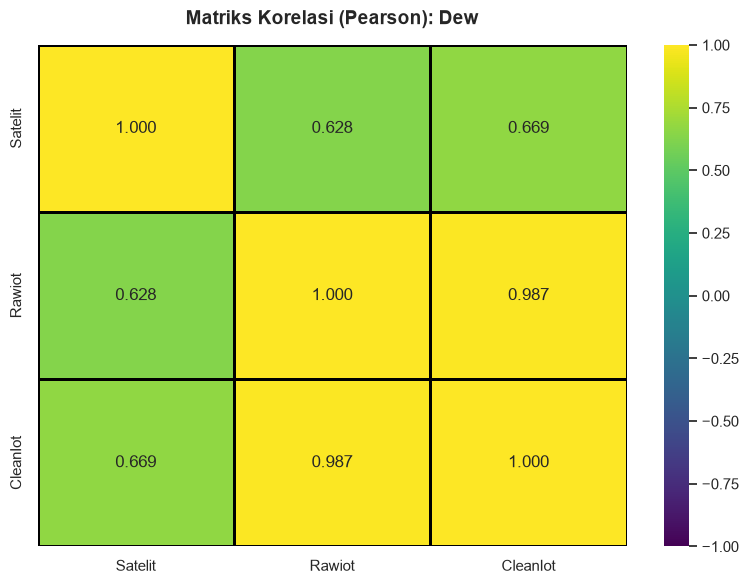

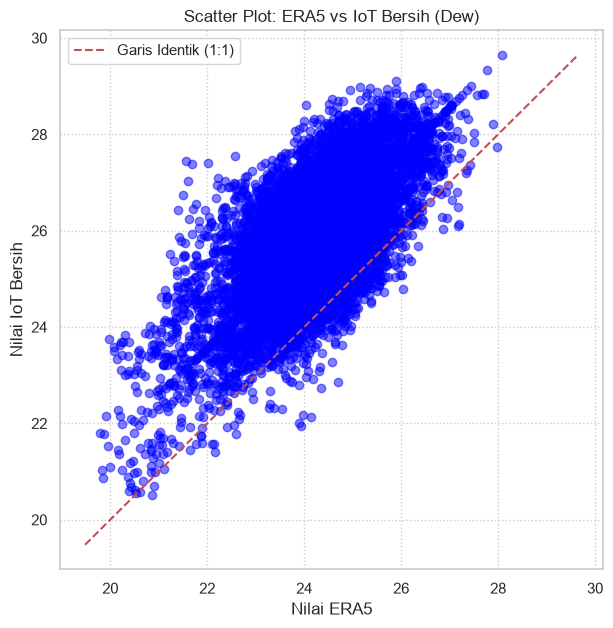

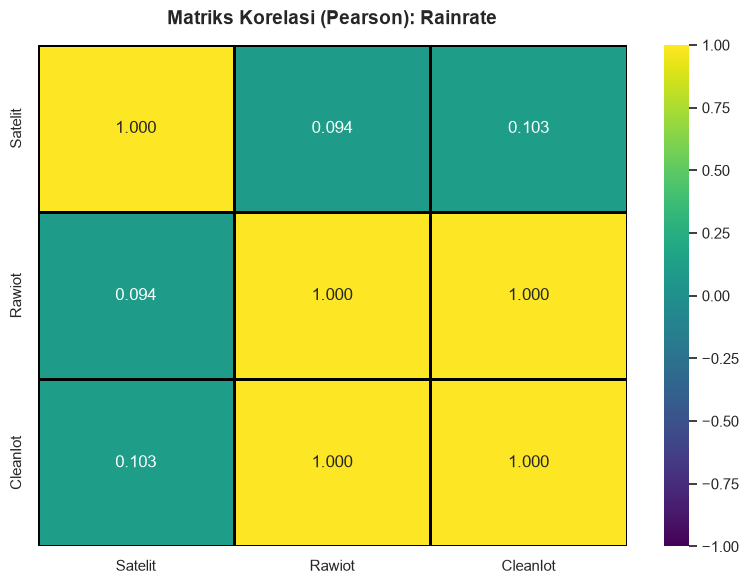

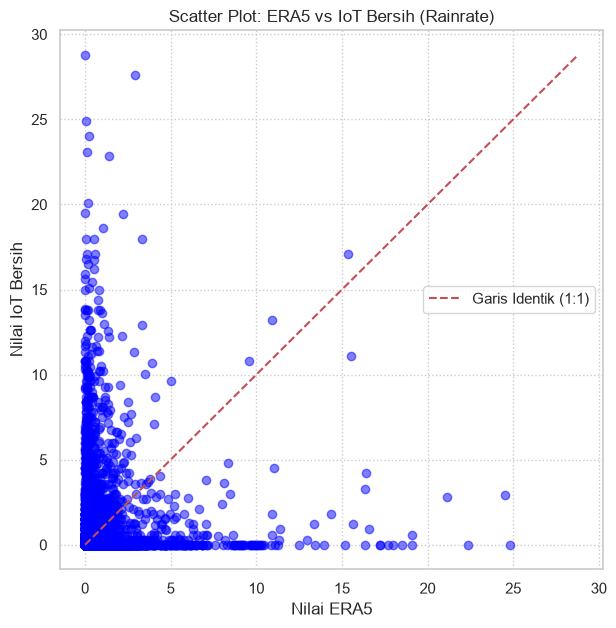

In [23]:
def cek_korelasi_transparansi(df_raw, df_clean, df_era5, era5_mapping, variabel='temperature'):
    """
    Membuat Matriks Korelasi (Heatmap) untuk membuktikan apakah 
    data IoT Bersih itu hasil jiplakan 100% dari ERA5 atau bukan.
    """
    print(f" MENGHITUNG MATRIKS KORELASI UNTUK: {variabel.upper()}")

    # Siapkan DataFrame arena pertarungan
    df_korelasi = pd.DataFrame(index=df_clean.index)

    # 1. Masukkan data ERA5 (satelit)
    col_era5 = era5_mapping.get(variabel)
    if not col_era5 and variabel == 'rainrate':
        col_era5 = era5_mapping.get('rainrate', 'rain')
    if not col_era5 and (variabel == 'dew' or variabel == 'dewpoint'):
        col_era5 = era5_mapping.get('dew') or era5_mapping.get('dewpoint')

    if col_era5 and col_era5 in df_era5.columns:
        # Menyamakan index ERA5 ke master index untuk amannya
        df_korelasi['Satelit'] = df_era5[col_era5].reindex(df_clean.index)

    # 2. Masukkan data IoT Mentah (Kotor)
    col_raw = variabel
    if col_raw not in df_raw.columns:
        if col_raw == 'dew' and 'dewpoint' in df_raw.columns:
            col_raw = 'dewpoint'
        elif col_raw == 'dewpoint' and 'dew' in df_raw.columns:
            col_raw = 'dew'

    if col_raw in df_raw.columns:
        df_korelasi['Rawiot'] = df_raw[col_raw]

    # 3. Masukkan data IoT Bersih (Imputasi)
    col_clean = variabel
    if col_clean not in df_clean.columns:
        if col_clean == 'dew' and 'dewpoint' in df_clean.columns:
            col_clean = 'dewpoint'
        elif col_clean == 'dewpoint' and 'dew' in df_clean.columns:
            col_clean = 'dew'

    if col_clean in df_clean.columns:
        df_korelasi['CleanIot'] = df_clean[col_clean]

    # Tampilkan persentase NaN di IoT Mentah (Ini untuk membuktikan diagnosis kita!)
    if 'Rawiot' in df_korelasi.columns:
        persen_nan = df_korelasi['Rawiot'].isnull().mean() * 100
        print(f"WARNING: Fakta Lapangan: Data IoT Mentah Anda kosong sebanyak {persen_nan:.2f}% pada rentang ini.")
    else:
        print("WARNING: Data IoT Mentah tidak memiliki variabel ini.")

    # Hitung Korelasi Pearson
    corr_matrix = df_korelasi.corr()

    # --- VISUALISASI HEATMAP ---
    plt.figure(figsize=(8, 6))

    # Buat Heatmap
    sns.heatmap(corr_matrix, 
                annot=True,          # Tampilkan angka di dalam kotak
                cmap='viridis',     # Warna merah (korelasi 1) ke biru (korelasi -1)
                vmin=-1, vmax=1,     # Batas nilai korelasi
                fmt=".3f",           # Tampilkan 3 angka di belakang koma
                linewidths=1, 
                linecolor='black')

    plt.title(f'Matriks Korelasi (Pearson): {variabel.capitalize()}', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    # plt.show()

    # --- VISUALISASI SCATTER PLOT (Opsional tapi mematikan) ---
    plt.figure(figsize=(7, 7))
    if 'Satelit' in df_korelasi.columns and 'CleanIot' in df_korelasi.columns:
        plt.scatter(df_korelasi['Satelit'], df_korelasi['CleanIot'], alpha=0.5, color='blue')
        max_val = max(df_korelasi['Satelit'].max(), df_korelasi['CleanIot'].max())
        min_val = min(df_korelasi['Satelit'].min(), df_korelasi['CleanIot'].min())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Garis Identik (1:1)')

    plt.title(f'Scatter Plot: ERA5 vs IoT Bersih ({variabel.capitalize()})')
    plt.xlabel('Nilai ERA5')
    plt.ylabel('Nilai IoT Bersih')
    plt.legend()
    plt.grid(True, linestyle=':')
    # plt.show()


# ==============================================================================
# CARA EKSEKUSI
# ==============================================================================
# Coba jalankan untuk rainrate atau temperature
cek_korelasi_transparansi(df_raw_05, df_clean_05, df_era5, era5_mapping, variabel='temperature')
cek_korelasi_transparansi(df_raw_05, df_clean_05, df_era5, era5_mapping, variabel='humidity')
cek_korelasi_transparansi(df_raw_05, df_clean_05, df_era5, era5_mapping, variabel='pressure')
cek_korelasi_transparansi(df_raw_05, df_clean_05, df_era5, era5_mapping, variabel='dew')
cek_korelasi_transparansi(df_raw_05, df_clean_05, df_era5, era5_mapping, variabel='rainrate')


Memuat data curah hujan pembanding untuk visualisasi korelasi...


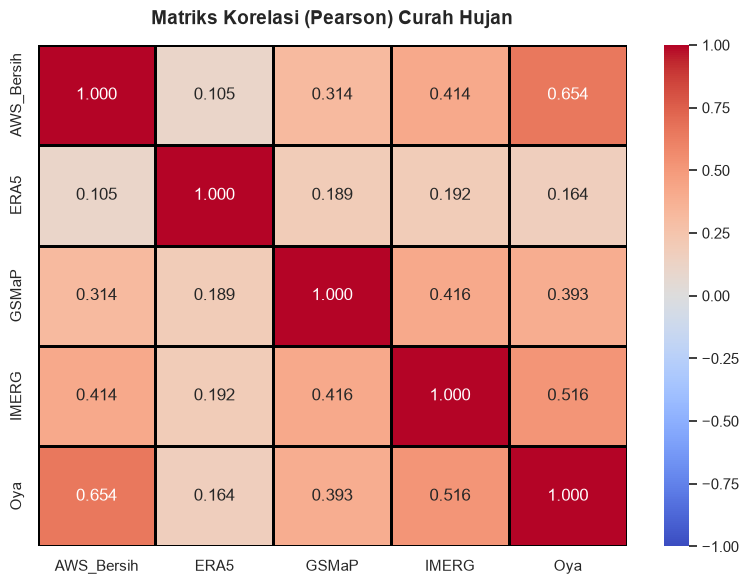

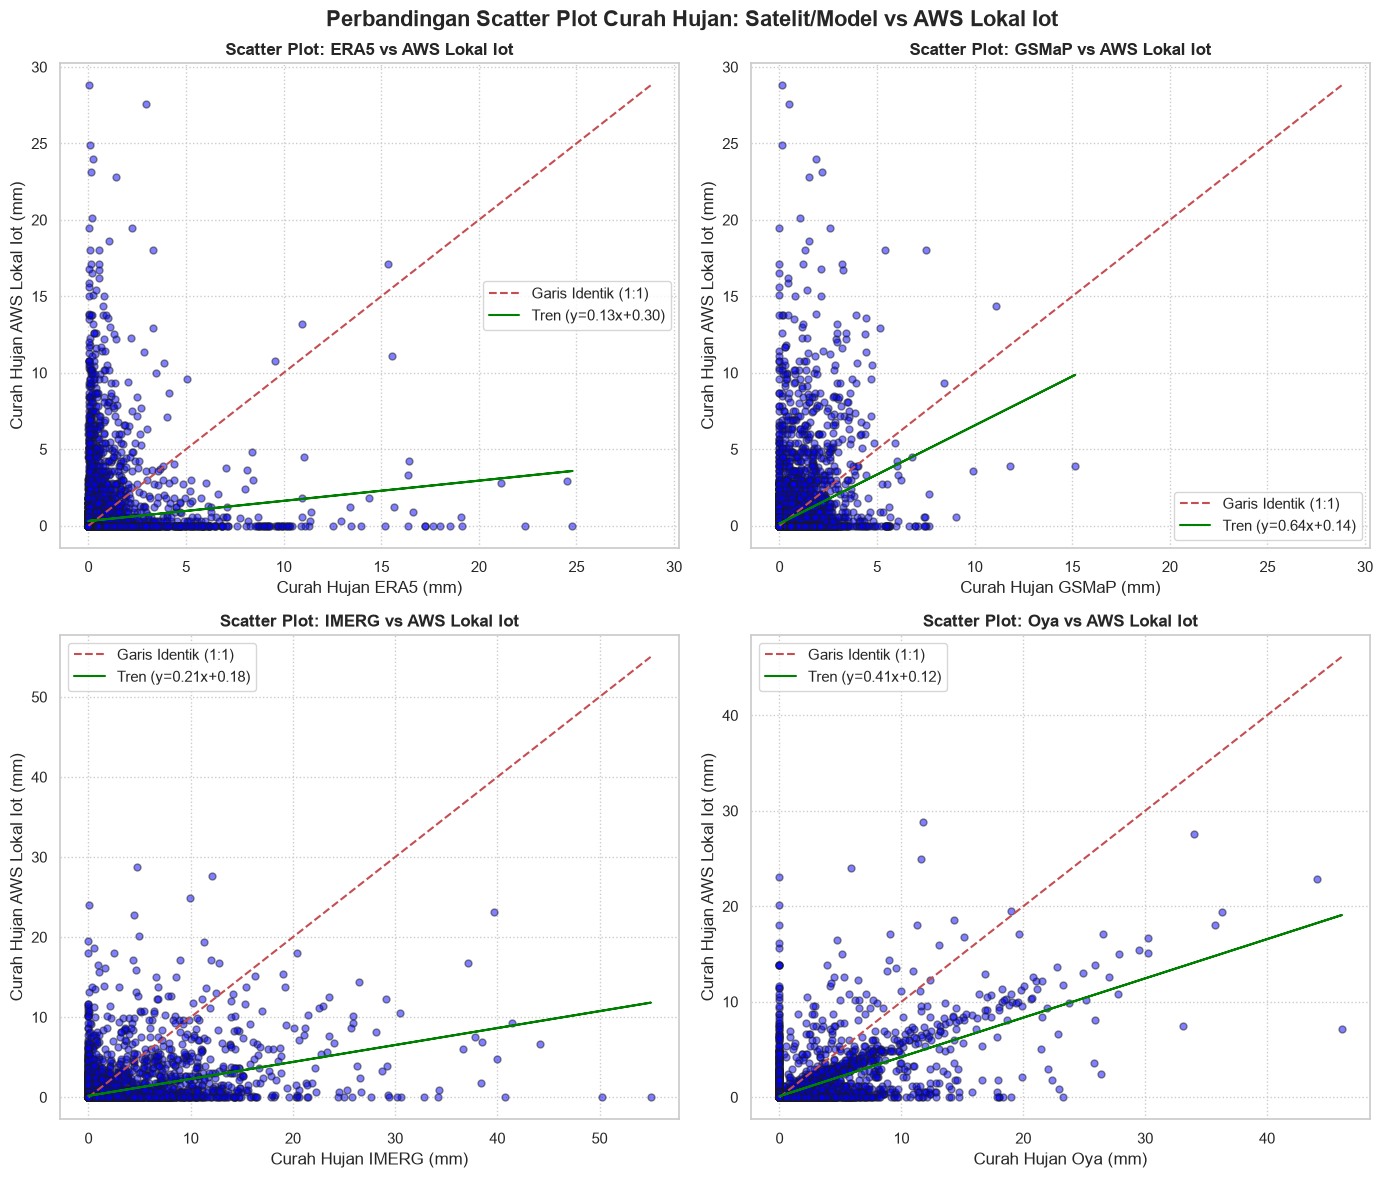

In [24]:
# ==============================================================================
# VISUALISASI KORELASI HUJAN: AWS BERSIH VS DATASET LAIN (IMERG, GSMaP, ERA5, Oya)
# ==============================================================================
def plot_korelasi_hujan(df_clean, df_era5, start_time, end_time):
    """
    Membuat visualisasi korelasi curah hujan antara hasil imputasi AWS (IoT) 
    dengan dataset curah hujan satelit/model referensi lainnya (IMERG, GSMaP, ERA5, Oya).
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    print("Memuat data curah hujan pembanding untuk visualisasi korelasi...")
    master_index = pd.date_range(start=start_time, end=end_time, freq='h', tz='UTC')
    
    # 1. AWS Bersih (df_clean_05)
    df_aws_hourly = df_clean.reindex(master_index)['rainrate'].fillna(0.0)
    
    # 2. ERA5
    df_era5_hourly = df_era5.reindex(master_index)['rain_mm'].fillna(0.0)
    
    # 3. GSMaP
    df_gsmap = pd.read_csv(GSMAP_PATH)
    df_gsmap['timestamp'] = pd.to_datetime(df_gsmap['datetime_utc'], utc=True)
    df_gsmap_hourly = df_gsmap.set_index('timestamp').resample('1h').sum().reindex(master_index)['hourlyPrecipRateGC'].fillna(0.0)
    
    # 4. IMERG
    df_imerg = pd.read_csv(IMERG_PATH)
    df_imerg['timestamp'] = pd.to_datetime(df_imerg['datetime_utc'], utc=True)
    df_imerg_hourly = df_imerg.set_index('timestamp').resample('1h').sum().reindex(master_index)['precipitation'].fillna(0.0)
    
    # 5. Oya
    df_oya = pd.read_csv(OYA_PATH)
    df_oya['timestamp'] = pd.to_datetime(df_oya['datetime_utc'], utc=True)
    df_oya_hourly = df_oya.set_index('timestamp').resample('1h').sum().reindex(master_index)['precipitation_mmhr'].fillna(0.0)
    
    # Gabungkan ke dalam satu DataFrame untuk analisis korelasi
    df_rain = pd.DataFrame({
        'AWS_Bersih': df_aws_hourly,
        'ERA5': df_era5_hourly,
        'GSMaP': df_gsmap_hourly,
        'IMERG': df_imerg_hourly,
        'Oya': df_oya_hourly
    })
    
    # --- 1. MATRIKS KORELASI (HEATMAP) ---
    corr_matrix = df_rain.corr(method='pearson')
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, 
                annot=True,          # Tampilkan nilai di dalam kotak
                cmap='coolwarm',     # Gradasi warna cool-to-warm
                vmin=-1, vmax=1,     # Batas korelasi
                fmt=".3f",           # 3 angka di belakang koma
                linewidths=1, 
                linecolor='black')
    plt.title('Matriks Korelasi (Pearson) Curah Hujan', fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
    
    # --- 2. SCATTER PLOTS (AWS Bersih vs Dataset Lain) ---
    datasets = ['ERA5', 'GSMaP', 'IMERG', 'Oya']
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.ravel()
    
    for i, dataset in enumerate(datasets):
        ax = axes[i]
        ax.scatter(df_rain[dataset], df_rain['AWS_Bersih'], alpha=0.5, color='blue', edgecolor='k', s=25)
        
        # Garis 1:1 (Identitas)
        max_val = max(df_rain[dataset].max(), df_rain['AWS_Bersih'].max())
        min_val = min(df_rain[dataset].min(), df_rain['AWS_Bersih'].min())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Garis Identik (1:1)')
        
        # Garis Tren Regresi Linear
        valid_mask = df_rain[dataset].notna() & df_rain['AWS_Bersih'].notna()
        if valid_mask.sum() > 1:
            m, c = np.polyfit(df_rain.loc[valid_mask, dataset], df_rain.loc[valid_mask, 'AWS_Bersih'], 1)
            ax.plot(df_rain[dataset], m*df_rain[dataset] + c, color='green', label=f'Tren (y={m:.2f}x+{c:.2f})')
            
        ax.set_title(f'Scatter Plot: {dataset} vs AWS Lokal Iot', fontsize=12, fontweight='bold')
        ax.set_xlabel(f'Curah Hujan {dataset} (mm)')
        ax.set_ylabel('Curah Hujan AWS Lokal Iot (mm)')
        ax.legend()
        ax.grid(True, linestyle=':')
        
    plt.suptitle('Perbandingan Scatter Plot Curah Hujan: Satelit/Model vs AWS Lokal Iot', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    return df_rain

# Jalankan plot korelasi
df_korelasi_hujan = plot_korelasi_hujan(df_clean_05, df_era5, start_uji, end_uji)


## Simulasi Sensitivitas BATAS_MAKSIMAL_PER_MENIT

Sektor ini menyajikan analisis sensitivitas untuk menguji pengaruh variasi nilai parameter filter outlier curah hujan menit-ke-menit (`BATAS_MAKSIMAL_PER_MENIT`) terhadap kualitas data hasil pembersihan.
- Level threshold yang diuji: `1.0, 1.15, 1.50, 1.75, 2.0, 2.5` (default), `3.0, 4.0` mm/menit.
- Performa diuji dengan membandingkan data bersih AWS hasil filter terhadap data satelit referensi (**GSMaP, IMERG, Oya**) menggunakan metrik **MAE**, **RMSE**, dan **Korelasi Pearson** pada periode evaluasi **2025-01-01 s.d. 2026-05-31**.

### Tabel Metrik Sensitivitas Threshold Pembersihan AWS vs Satelit

,Threshold,Satelit,MAE,RMSE,Korelasi
0,0.50,GSMaP,0.3983,1.0435,0.3525
1,0.50,IMERG,0.7694,2.6761,0.4490
2,0.50,Oya,0.4671,1.7868,0.7294
3,0.80,GSMaP,0.4462,1.2193,0.3427
4,0.80,IMERG,0.7880,2.6633,0.4406
5,0.80,Oya,0.4853,1.7742,0.6896
6,1.00,GSMaP,0.4980,1.5088,0.3128
7,1.00,IMERG,0.8160,2.7145,0.4135
8,1.00,Oya,0.5082,1.8150,0.6481
9,1.15,GSMaP,0.4980,1.5088,0.3128


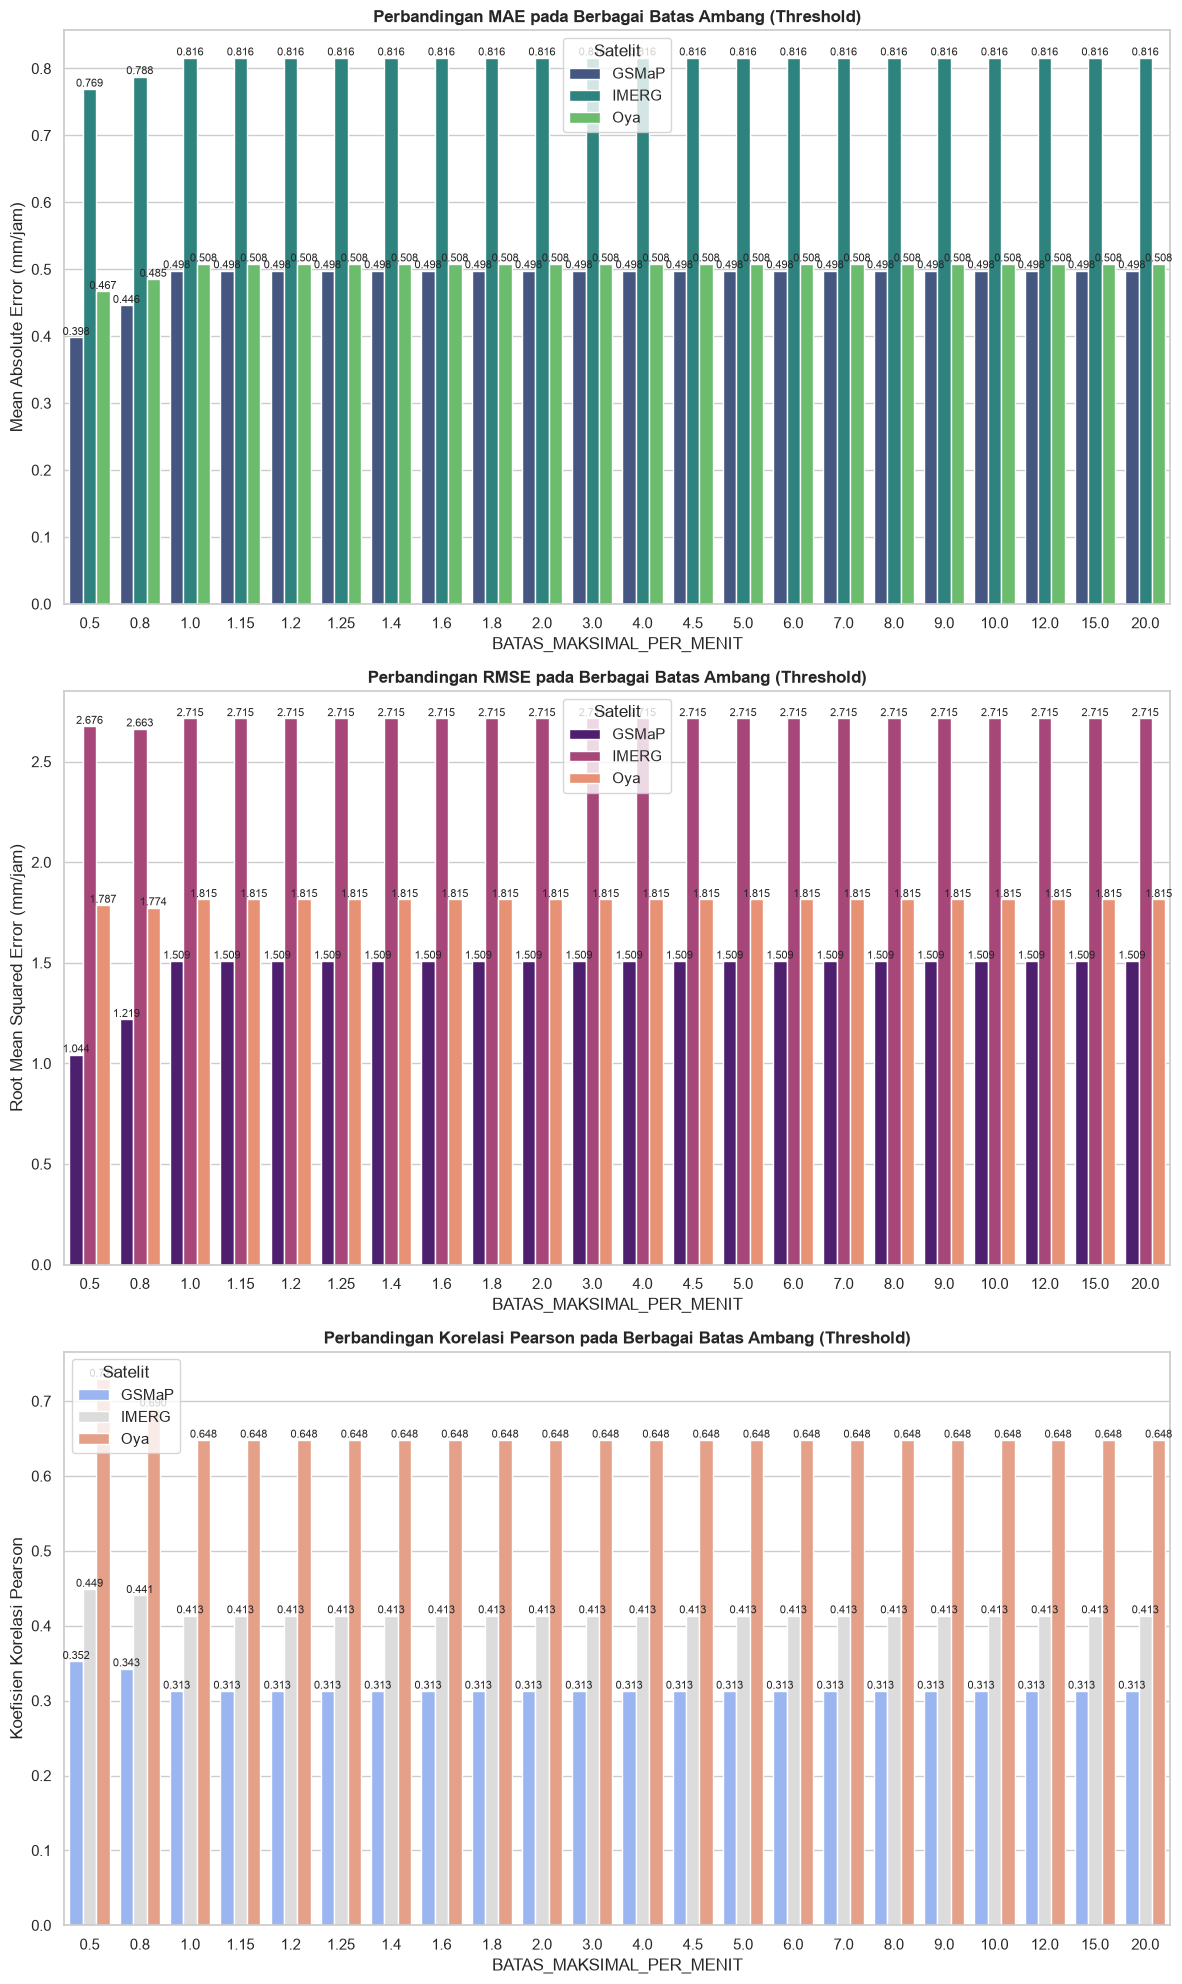

In [25]:
# Sel 13: Simulasi Sensitivitas BATAS_MAKSIMAL_PER_MENIT terhadap Satelit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. Setup parameter dan timeline
thresholds = [0.5, 0.8, 1.0, 1.15,1.20, 1.25, 1.40, 1.6, 1.8, 2.0, 3.0, 4.0, 4.5, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 12.0, 15.0, 20.0]
master_index = pd.date_range(start=start_uji, end=end_uji, freq='h', tz='UTC')

# 2. Load satellite data
df_gsmap = pd.read_csv(GSMAP_PATH)
df_gsmap['timestamp'] = pd.to_datetime(df_gsmap['datetime_utc'], utc=True)
df_gsmap_hourly = df_gsmap.set_index('timestamp').resample('1h').sum().reindex(master_index)['hourlyPrecipRateGC'].fillna(0.0)

df_imerg = pd.read_csv(IMERG_PATH)
df_imerg['timestamp'] = pd.to_datetime(df_imerg['datetime_utc'], utc=True)
df_imerg_hourly = df_imerg.set_index('timestamp').resample('1h').sum().reindex(master_index)['precipitation'].fillna(0.0)

df_oya = pd.read_csv(OYA_PATH)
df_oya['timestamp'] = pd.to_datetime(df_oya['datetime_utc'], utc=True)
df_oya_hourly = df_oya.set_index('timestamp').resample('1h').sum().reindex(master_index)['precipitation_mmhr'].fillna(0.0)

satellites = {
    'GSMaP': df_gsmap_hourly,
    'IMERG': df_imerg_hourly,
    'Oya': df_oya_hourly
}

# 3. Jalankan simulasi pembersihan
simulation_rows = []

for thresh in thresholds:
    # Buat copy dari data mentah untuk dibersihkan
    df_temp = cuaca5.copy()
    
    # Deteksi increment & penanganan reset
    df_temp['delta_raw'] = df_temp['rainrate'].diff()
    df_temp['actual_increment'] = np.where(
        df_temp['delta_raw'] < 0, 
        df_temp['rainrate'],      
        df_temp['delta_raw']      
    )
    df_temp['actual_increment'] = df_temp['actual_increment'].fillna(0).clip(lower=0)
    
    # Hancurkan outlier
    kondisi_outlier = df_temp['actual_increment'] > thresh
    df_temp.loc[kondisi_outlier, 'actual_increment'] = 0.0
    
    # Standarisasi tip
    df_temp['tips_count'] = np.round(df_temp['actual_increment'] / 0.3215)
    df_temp['increment_fixed'] = df_temp['tips_count'] * 0.3215
    
    # Rekonstruksi per jam
    df_temp['rainrate'] = df_temp.groupby(df_temp.index.floor('h'))['increment_fixed'].cumsum()
    
    # Agregasi
    df_hourly_thresh = df_temp.resample('h').agg({'rainrate': 'max'})
    
    # Reindex & Imputasi
    if df_hourly_thresh.index.tz is None:
        df_hourly_thresh.index = df_hourly_thresh.index.tz_localize('UTC')
    else:
        df_hourly_thresh.index = df_hourly_thresh.index.tz_convert('UTC')
        
    df_reindexed = df_hourly_thresh.reindex(master_index)
    df_reindexed['rainrate'] = df_reindexed['rainrate'].fillna(df_rain_median)
    df_reindexed['rainrate'] = df_reindexed['rainrate'].fillna(0.0)
    
    aws_clean = df_reindexed['rainrate']
    
    # Hitung metrik pembanding
    for sat_name, sat_data in satellites.items():
        mae = np.mean(np.abs(aws_clean - sat_data))
        rmse = np.sqrt(np.mean((aws_clean - sat_data)**2))
        corr = aws_clean.corr(sat_data, method='pearson')
        
        simulation_rows.append({
            'Threshold': thresh,
            'Satelit': sat_name,
            'MAE': round(mae, 4),
            'RMSE': round(rmse, 4),
            'Korelasi': round(corr, 4)
        })

df_sim_results = pd.DataFrame(simulation_rows)

# 4. Sajikan Tabel Perbandingan
display(Markdown("### Tabel Metrik Sensitivitas Threshold Pembersihan AWS vs Satelit"))
pd.set_option('display.max_rows', 100)
display(df_sim_results)

# 5. Visualisasi Bar Chart Grouped
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 20))

# Subplot MAE
sns.barplot(data=df_sim_results, x='Threshold', y='MAE', hue='Satelit', ax=axes[0], palette='viridis')
axes[0].set_title('Perbandingan MAE pada Berbagai Batas Ambang (Threshold)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('BATAS_MAKSIMAL_PER_MENIT')
axes[0].set_ylabel('Mean Absolute Error (mm/jam)')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', fontsize=8)
    
# Subplot RMSE
sns.barplot(data=df_sim_results, x='Threshold', y='RMSE', hue='Satelit', ax=axes[1], palette='magma')
axes[1].set_title('Perbandingan RMSE pada Berbagai Batas Ambang (Threshold)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('BATAS_MAKSIMAL_PER_MENIT')
axes[1].set_ylabel('Root Mean Squared Error (mm/jam)')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', fontsize=8)
    
# Subplot Korelasi
sns.barplot(data=df_sim_results, x='Threshold', y='Korelasi', hue='Satelit', ax=axes[2], palette='coolwarm')
axes[2].set_title('Perbandingan Korelasi Pearson pada Berbagai Batas Ambang (Threshold)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('BATAS_MAKSIMAL_PER_MENIT')
axes[2].set_ylabel('Koefisien Korelasi Pearson')
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.3f', fontsize=8)
    
plt.tight_layout()
plt.show()


## Analisis Statistik Deskriptif Akhir Data AWS Bersih

Sektor ini menyajikan ringkasan statistik deskriptif akhir untuk seluruh dataset AWS yang telah dibersihkan (**Minimum, Maksimum, Rata-rata/Mean, dan Median/50%**).
Analisis ini berfungsi sebagai QC akhir untuk memastikan batas fisis variabel cuaca (seperti Kelembaban maksimal <= 100% dan rainrate >= 0.0) sudah terpenuhi secara sempurna.

In [26]:
# Sel 14: Statistik Deskriptif Akhir Data AWS Bersih
import pandas as pd
from IPython.display import display, Markdown

weather_cols = ['temperature', 'humidity', 'pressure', 'dew', 'rainrate']
clean_dfs = {k: v for k, v in locals().items() if k.startswith('df_clean') and isinstance(v, pd.DataFrame)}

if clean_dfs:
    for name, df in clean_dfs.items():
        display(Markdown(f"### 📊 Statistik Deskriptif Akhir Data AWS Bersih (`{name}`)"))
        existing_cols = [c for c in weather_cols if c in df.columns]
        if existing_cols:
            stats_df = df[existing_cols].describe().transpose()
            stats_df = stats_df[['min', 'max', 'mean', '50%']]
            stats_df.columns = ['Nilai Minimum', 'Nilai Maksimum', 'Rata-rata (Mean)', 'Median (50%)']
            display(stats_df.style.format({
                'Nilai Minimum': '{:.4f}',
                'Nilai Maksimum': '{:.4f}',
                'Rata-rata (Mean)': '{:.4f}',
                'Median (50%)': '{:.4f}'
            }))
        else:
            print(f"Tidak ada kolom cuaca standar di `{name}`.")
else:
    # Fallback manual jika dijalankan di cell kosong tanpa state memori penuh
    print("Tidak ditemukan DataFrame AWS Bersih (df_clean*) di namespace aktif!")


### 📊 Statistik Deskriptif Akhir Data AWS Bersih (`df_clean_05`)

,Nilai Minimum,Nilai Maksimum,Rata-rata (Mean),Median (50%)
temperature,20.5948,33.9989,28.0281,27.4399
humidity,56.3220,100.0000,88.0337,90.9422
pressure,1002.4965,1016.4218,1010.2421,1010.3374
dew,19.4796,29.6523,25.7422,25.7914
rainrate,0.0000,28.8000,0.3524,0.0000
